# 03B — Identification relative to the Probit–Normal environmental null

This notebook contains the full-sample empirical analysis for the Probit–Normal environmental framework used in the paper.

The three fitted models are:

- **M0**: Probit–Normal environmental null
- **M1**: M0 + Davis–Lo cumulative contagion
- **M2**: M0 + Torri threshold-type contagion

For each year *t*, the baseline default probability is allowed to fluctuate across periods,

*y_t ~ N(mu, sigma^2),  p_t = Phi(y_t),*

while the structural contagion parameters are time-independent.

No temporal dynamics are imposed on the annual latent environmental states.

## Scope

This notebook reproduces the full-sample M0–M2 analysis:

1. maximum-likelihood estimation;
2. Table III: likelihood / AIC / BIC comparison;
3. Table IV and Fig. 3: tail-risk and survival comparison;
4. Appendix variance decomposition (Table VII / Fig. 7);
5. Appendix directed KL separation among fitted M0–M2 distributions (Table VIII).

The static benchmark is handled in `03A_static_one_period_models.ipynb`.

Subperiod analysis and the two-component Gaussian-mixture environmental null M3 are intentionally left for separate notebooks.

## Data policy

The notebook first looks for the proprietary local file:

`data/M_1920_2023.csv`

If it is unavailable, it uses:

`data/M_1920_2023_synthetic.csv`

generated by `01_generate_synthetic_data.ipynb`.

Synthetic data reproduce the public computational workflow only; they do **not** reproduce the manuscript's empirical numerical results.

Outputs are written to:

- `pdata/` for numerical tables and diagnostics
- `figure/` for figures


In [2]:
from pathlib import Path
import random
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.display import display
from math import lgamma
from scipy.optimize import minimize, brentq
from scipy.stats import norm, multivariate_normal, binom
from scipy.special import gammaln, logsumexp as scipy_logsumexp
from numpy.polynomial.hermite import hermgauss

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
PDATA_DIR = ROOT / "pdata"
FIGURE_DIR = ROOT / "figure"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PDATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

REAL_DATA = DATA_DIR / "M_1920_2023.csv"
SYNTHETIC_DATA = DATA_DIR / "M_1920_2023_synthetic.csv"

if REAL_DATA.exists():
    DATA_FILE = REAL_DATA
    DATA_SOURCE = "REAL"
    print("=" * 72)
    print("DATA SOURCE: proprietary annual Moody's data")
    print(f"File: {DATA_FILE}")
    print("=" * 72)

elif SYNTHETIC_DATA.exists():
    DATA_FILE = SYNTHETIC_DATA
    DATA_SOURCE = "SYNTHETIC"
    print("=" * 72)
    print("DATA SOURCE: FULLY SYNTHETIC annual default data")
    print("The resulting numerical estimates will NOT reproduce the manuscript.")
    print(f"File: {DATA_FILE}")
    print("=" * 72)

else:
    raise FileNotFoundError(
        "\nNo annual default dataset was found.\n\n"
        "If you have authorized access to the proprietary data, place it at:\n"
        "    data/M_1920_2023.csv\n\n"
        "Otherwise first run:\n"
        "    01_generate_synthetic_data.ipynb\n\n"
        "which should create:\n"
        "    data/M_1920_2023_synthetic.csv\n"
    )

df = pd.read_csv(DATA_FILE)

EXPECTED_COLUMNS = [
    "Year", "ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"
]

missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[EXPECTED_COLUMNS].copy()
df["Year"] = pd.to_numeric(df["Year"], errors="raise").astype(int)

for c in ["ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"]:
    df[c] = pd.to_numeric(df[c], errors="raise").astype(int)

for key in ["ALL", "SG", "IG"]:
    valid = (
        (df[key] > 0)
        & (df[f"D_{key}"] >= 0)
        & (df[f"D_{key}"] <= df[key])
    )
    if not valid.all():
        raise ValueError(f"Invalid exposure/default counts for {key}")

NBAR = {
    key: int(round(df[key].mean()))
    for key in ["ALL", "SG", "IG"]
}

print(f"Rows: {len(df)}")
print(f"Years: {df['Year'].min()}–{df['Year'].max()}")
print(f"Representative fixed exposures: {NBAR}")
display(df.head())


DATA SOURCE: proprietary annual Moody's data
File: ./data/M_1920_2023.csv
Rows: 104
Years: 1920–2023
Representative fixed exposures: {'ALL': 2573, 'SG': 1008, 'IG': 1565}


,Year,ALL,D_ALL,SG,D_SG,IG,D_IG
0,1920,2674,33,831,25,1843,8
1,1921,2996,32,1163,25,1833,7
2,1922,3277,33,1305,23,1972,10
3,1923,3358,27,1290,22,2068,5
4,1924,3472,40,1297,37,2175,3


## 1. Numerical utilities and one-period conditional PMFs

The environmental models integrate the conditional one-period count distributions over a Probit–Normal distribution of the baseline default probability. The functions in this section are copied from the canonical analysis notebook. They will later be moved to `modules/` together with the shared functions used by 02 and 03A.


In [3]:
# =========================
# Numeric utilities
# =========================

def log_comb(n: int, k: int) -> float:
    """log( n choose k )"""
    return lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)

def logsumexp_arr(logw: np.ndarray) -> float:
    """stable log(sum(exp(logw))) for 1D array"""
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(logw - m)))

def logsumexp(x: float, y: float) -> float:
    """log(exp(x)+exp(y))"""
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.exp(x-m) + np.exp(y-m))

def logsubexp(a: float, b: float) -> float:
    """log(exp(a)-exp(b)) with a>b; otherwise -inf"""
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))

def normalize_logpmf(logpmf: np.ndarray) -> np.ndarray:
    """Normalize log-PMF array to PMF (handles -inf safely)."""
    logpmf = np.where(np.isfinite(logpmf), logpmf, -np.inf)
    m = np.max(logpmf)
    if not np.isfinite(m):
        return np.full_like(logpmf, np.nan, dtype=float)
    z = np.sum(np.exp(logpmf - m))
    return np.exp(logpmf - (m + np.log(z)))

# =========================
# Tail & moments utilities
# =========================

def var_from_pmf(pmf: np.ndarray, alpha: float = 0.99, side: str = "left") -> int:
    """VaRα = inf{h: P(L<=h) >= α}."""
    cdf = np.cumsum(pmf)
    return int(np.searchsorted(cdf, alpha, side=side))

def es_from_pmf(pmf: np.ndarray, var_h: int, strict: bool = False) -> float:
    """
    ESα: default is E[L | L >= VaRα] (strict=False).
    strict=True -> E[L | L > VaRα]
    """
    pmf = np.asarray(pmf, dtype=float)
    x = np.arange(len(pmf))
    start = var_h + 1 if strict else var_h
    tail = pmf[start:]
    tp = tail.sum()
    if tp <= 0:
        return np.nan
    return float((x[start:] * tail).sum() / tp)

def moments_from_pmf(pmf: np.ndarray):
    x = np.arange(len(pmf))
    mean = float((x*pmf).sum())
    var = float(((x-mean)**2 * pmf).sum())
    return mean, var

def m_rho_from_pmf(pmf: np.ndarray):
    """Return (m, rho, Var(L)) where m=E[L]/n, rho is pairwise default corr (exchangeable proxy)."""
    pmf = np.asarray(pmf, dtype=float)
    s = pmf.sum()
    if s <= 0:
        return np.nan, np.nan, np.nan
    pmf = pmf / s

    n = len(pmf) - 1
    x = np.arange(n+1)

    EL  = float((x * pmf).sum())
    EL2 = float(((x**2) * pmf).sum())
    varL = EL2 - EL**2

    if n <= 0:
        return np.nan, np.nan, varL

    m = EL / n
    denom = n*(n-1)*m*(1-m)
    if denom <= 1e-15:
        return m, np.nan, varL

    rho = (varL - n*m*(1-m)) / denom
    return m, rho, varL

def survival_from_pmf(pmf: np.ndarray) -> np.ndarray:
    """S[h] = P(L >= h)"""
    return np.flip(np.cumsum(np.flip(pmf)))

def tail_metrics_from_pmf(pmf: np.ndarray, alpha: float = 0.99, strict_es: bool = False):
    v = var_from_pmf(pmf, alpha=alpha)
    e = es_from_pmf(pmf, v, strict=strict_es)
    return dict(
        VaR=v,
        ES=e,
        ES_minus_VaR=(e - v) if np.isfinite(e) else np.nan,
        ES_over_VaR=(e / v) if (np.isfinite(e) and v > 0) else np.nan
    )

# Torri Model
def pmf_Torri(n: int, p: float, u: float, v: float) -> np.ndarray:
    """
    Torri (infectious default) PMF for L_n.
    Numerically stable (log-sum-exp).
    """
    a = p*(1-v)
    b = (1-p)*(1-u)
    c = (1-p)*u
    bc = b + c  # = 1-p

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    log_bc = -np.inf if bc <= 0 else np.log(bc)

    for h in range(n+1):
        # term0 = a^h * (b+c)^(n-h)
        if h == 0:
            log_a_h = 0.0
        else:
            log_a_h = -np.inf if a <= 0 else h*np.log(a)
        log_term0 = log_a_h + (n-h)*log_bc

        # term1 = ((p+b)^h - (a+b)^h) * c^(n-h)
        if h == 0:
            log_term1 = -np.inf
        else:
            # c^(n-h)
            if (n-h) == 0:
                log_c_pow = 0.0
            else:
                log_c_pow = -np.inf if c <= 0 else (n-h)*np.log(c)

            X = p + b
            Y = a + b

            if log_c_pow == -np.inf or X <= 0 or Y <= 0:
                log_term1 = -np.inf
            else:
                logXh = h*np.log(X)
                logYh = h*np.log(Y)
                log_diff = logsubexp(logXh, logYh)
                log_term1 = -np.inf if log_diff == -np.inf else (log_diff + log_c_pow)

        pmf_log[h] = log_comb(n, h) + logsumexp2(log_term0, log_term1)

    return normalize_logpmf(pmf_log)

def moments_from_params_Torri(n: int, p: float, u: float, v: float):
    """Closed-form (m, rho) for Torri parameterization used in this notebook."""
    b = (1-p)*(1-u)
    s = 1 - p*v

    # mean (fraction)
    m = p + b*(1 - s**(n-1))

    # pair moment term
    a_alt = s + p - 1
    s_pow = s**(n-2) if n > 2 else 1.0
    E = (p+b)**2 - b*(2*a_alt + b)*s_pow

    cov = E - m**2
    den = m*(1-m)
    rho = np.nan if den <= 1e-15 else cov/den
    return float(m), float(rho)

# Lo-Davis Model
def pmf_LD(n: int, p: float, q: float) -> np.ndarray:
    """
    Lo–Davis Infectious Default Model PMF via mixture:
      K ~ Bin(n,p), L|K=k = k + Bin(n-k, r_k), r_k = 1 - (1-q)^k
    Stable implementation using expm1/log1p and log-sum-exp.
    """
    if not (0.0 <= p <= 1.0 and 0.0 <= q <= 1.0):
        raise ValueError("p and q must be in [0,1].")

    # log P(K=k)
    logP_K = np.full(n+1, -np.inf, dtype=float)
    if p == 0.0:
        logP_K[0] = 0.0
    elif p == 1.0:
        logP_K[n] = 0.0
    else:
        log_p = np.log(p)
        log_1mp = np.log1p(-p)
        for k in range(n+1):
            logP_K[k] = log_comb(n, k) + k*log_p + (n-k)*log_1mp

    # r_k = 1 - (1-q)^k  (stable)
    r = np.zeros(n+1, dtype=float)
    if q == 0.0:
        r[:] = 0.0
    elif q == 1.0:
        r[0] = 0.0
        r[1:] = 1.0
    else:
        l = np.log1p(-q)
        ks = np.arange(n+1, dtype=float)
        r = -np.expm1(ks * l)

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    for h in range(n+1):
        # sum over k=0..h
        terms = np.full(h+1, -np.inf, dtype=float)
        for k in range(h+1):
            if not np.isfinite(logP_K[k]):
                continue
            t = h - k
            nk = n - k
            rk = r[k]
            if t < 0 or t > nk:
                continue

            if rk == 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk == 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_rk = np.log(rk)
                log_1mrk = np.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_rk + (nk-t)*log_1mrk

            terms[k] = logP_K[k] + log_bin

        pmf_log[h] = logsumexp_arr(terms)

    return normalize_logpmf(pmf_log)

def m_rho_LD(n: int, p: float, q: float):
    """
    Closed-form (m, rhoZ) for Lo–Davis.
    m = 1 - (1-p)*(1-qp)^(n-1)
    Cov = (1-p)^2 * [ (1 - 2pq + p q^2)^(n-2) - (1-pq)^(2(n-1)) ]
    rho = Cov / (m(1-m))
    """
    m = 1.0 - (1.0 - p) * (1.0 - q*p)**(n-1)
    if n < 2:
        return float(m), np.nan
    termA = (1.0 - 2.0*p*q + p*(q**2))**(n-2)
    termB = (1.0 - p*q)**(2*(n-1))
    cov = (1.0 - p)**2 * (termA - termB)
    var = m*(1.0-m)
    rho = cov/var if var > 1e-15 else np.nan
    return float(m), float(rho)

def check_mrho_formula_vs_pmf_LD(n: int, p: float, q: float):
    pmf = pmf_LD(n, p, q)
    m_pmf, rho_pmf, _ = m_rho_from_pmf(pmf)
    m_f, rho_f = m_rho_LD(n, p, q)
    return dict(m_pmf=m_pmf, m_formula=m_f, diff_m=m_pmf-m_f,
                rho_pmf=rho_pmf, rho_formula=rho_f, diff_rho=rho_pmf-rho_f,
                pmf_sum=float(pmf.sum()))

# Vasicek Model
def phi2_aa(a: float, rhoA: float) -> float:
    cov = np.array([[1.0, rhoA],
                    [rhoA, 1.0]])
    return float(multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov))

def default_corr_from_asset_corr(m: float, rhoA: float) -> float:
    a = norm.ppf(m)
    q = phi2_aa(a, rhoA)
    return float((q - m*m) / (m*(1.0 - m)))

def invert_asset_corr_from_default_corr(m: float, rho_target: float, tol: float = 1e-10) -> float:
    """Solve rhoA in [0, 0.999999] such that Corr(Zi,Zj)=rho_target."""
    if not (0.0 < m < 1.0):
        raise ValueError("m must be in (0,1).")
    if not (-1.0 < rho_target < 1.0):
        raise ValueError("rho_target must be in (-1,1).")

    def F(rhoA):
        return default_corr_from_asset_corr(m, rhoA) - rho_target

    return float(brentq(F, 0.0, 0.999999, xtol=tol, rtol=tol, maxiter=200))

def pmf_Vas(n: int, m: float, rhoA: float, n_gh: int = 60) -> np.ndarray:
    """
    L|Y=y ~ Bin(n, p(y)), p(y)=Phi((a - sqrt(rhoA)*y)/sqrt(1-rhoA))
    PMF = E[ BinPMF(h; n, p(Y)) ] using Gauss-Hermite + log-sum-exp.
    """
    a = norm.ppf(m)
    s = np.sqrt(rhoA)
    t = np.sqrt(1.0 - rhoA)

    x, w = hermgauss(n_gh)
    y = np.sqrt(2.0) * x
    log_w = np.log(w) - 0.5*np.log(np.pi)

    p = norm.cdf((a - s*y) / t)
    p = np.clip(p, 1e-15, 1.0 - 1e-15)
    logp = np.log(p)
    log1mp = np.log1p(-p)

    hs = np.arange(n+1)
    logC = np.array([log_comb(n, h) for h in hs], dtype=float)

    log_bin = logC[None, :] + hs[None, :]*logp[:, None] + (n-hs)[None, :]*log1mp[:, None]
    log_terms = log_w[:, None] + log_bin

    m0 = np.max(log_terms, axis=0)
    pmf = np.exp(m0 + np.log(np.sum(np.exp(log_terms - m0[None, :]), axis=0)))

    pmf = np.maximum(pmf, 0.0)
    pmf = pmf / pmf.sum()
    return pmf


In [4]:
def log_pmf_Torri(n: int, h: int, p: float, u: float, v: float) -> float:
    # constraints (p strictly inside to avoid log(0) issues in bc=1-p)
    if not (0.0 < p < 1.0 and 0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return -np.inf
    if not (0 <= h <= n):
        return -np.inf

    a = p*(1.0 - v)
    b = (1.0 - p)*(1.0 - u)
    c = (1.0 - p)*u
    bc = b + c  # = 1-p

    # --- term0 = a^h * (b+c)^(n-h) ---
    # log term0
    if h > 0:
        if a <= 0.0:
            t0 = -np.inf
        else:
            t0 = h*math.log(a) + (n-h)*math.log(bc)
    else:
        # a^0 = 1
        t0 = (n-h)*math.log(bc)

    # --- term1 = ((p+b)^h - (a+b)^h) * c^(n-h) ---
    pb = p + b
    ab = a + b

    if h == 0:
        t1 = -np.inf
    else:
        # if v=0 -> a=p -> pb==ab -> difference 0
        if pb <= 0.0 or ab <= 0.0:
            t1 = -np.inf
        else:
            lp = h*math.log(pb)
            la = h*math.log(ab)

            # stable log(exp(lp)-exp(la)) (requires lp>la)
            diff_log = logsubexp(lp, la)
            if diff_log == -np.inf:
                t1 = -np.inf
            else:
                if (n-h) > 0:
                    if c <= 0.0:
                        t1 = -np.inf
                    else:
                        t1 = diff_log + (n-h)*math.log(c)
                else:
                    t1 = diff_log

    # combine
    inner = logsumexp(t0, t1)
    if inner == -np.inf:
        return -np.inf

    return log_comb(n, h) + inner


In [5]:
def logsumexp_vec(logw):
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(logw - m))))

def log_pmf_LD_1pt(n, h, p, q):
    """
    LD mixture:
      K ~ Bin(n,p)
      L|K=k = k + Bin(n-k, r_k),  r_k = 1 - (1-q)^k
    Return log P(L=h) by summing over k=0..h
    """
    if not (0 <= h <= n):
        return -np.inf

    # numerical guards
    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))

    log_p  = math.log(p)
    log_1p = math.log1p(-p)
    log_1q = math.log1p(-q)

    terms = np.full(h+1, -np.inf, dtype=float)

    for k in range(0, h+1):
        t = h - k
        nk = n - k
        if t < 0 or t > nk:
            continue

        # log P(K=k)
        log_pk = log_comb(n, k) + k*log_p + (n-k)*log_1p

        # r_k = 1 - (1-q)^k  (stable)
        if k == 0:
            if t != 0:
                continue
            log_bin = 0.0
        else:
            rk = -math.expm1(k * log_1q)  # stable 1-(1-q)^k
            # handle extreme rk
            if rk <= 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk >= 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_r  = math.log(rk)
                log_1r = math.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_r + (nk-t)*log_1r

        terms[k] = log_pk + log_bin

    return logsumexp_vec(terms)


## 2. Shared environmental-model helpers

These utilities handle parameter transformations, grouped annual observations, fixed-*n* scaling, Gauss–Hermite integration, and the conditional moments required for the variance decomposition.


In [6]:
# ==========================================
# Common helpers (define ONCE)
# ==========================================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def inv_softplus(s):
    s = float(s)
    if s <= 0:
        raise ValueError("softplus inverse requires s > 0")
    return s + np.log(-np.expm1(-s))

def _clean_nh(series_n, series_h):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    tmp = tmp[(tmp["n"] > 0) & (tmp["h"] >= 0) & (tmp["h"] <= tmp["n"])].copy()
    return tmp

def make_grouped_nh(series_n, series_h):
    tmp = _clean_nh(series_n, series_h)
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)
    return n_arr, h_arr, c_arr

def _clean_nL(df, key):
    n_vals = df[key].astype(int).to_numpy()
    L_vals = df["D_" + key].astype(int).to_numpy()
    mask = (
        (n_vals > 0) &
        (L_vals >= 0) &
        (L_vals <= n_vals) &
        np.isfinite(n_vals) &
        np.isfinite(L_vals)
    )
    return n_vals[mask].astype(int), L_vals[mask].astype(int)

def scaled_counts(n_vals, L_vals, nbar):
    n_vals = np.asarray(n_vals, dtype=float)
    L_vals = np.asarray(L_vals, dtype=float)
    Ls = np.rint(L_vals * (float(nbar) / n_vals)).astype(int)
    Ls = np.maximum(Ls, 0)
    return Ls

def gh_normal_weights(mu, sigma, GH_N):
    x, w = hermgauss(int(GH_N))
    y = mu + math.sqrt(2.0) * sigma * x
    wn = w / math.sqrt(math.pi)
    wn = wn / np.sum(wn)
    return y, wn

def aggregate_m_q_to_rho(m, q):
    den = m * (1.0 - m)
    if den <= 1e-15:
        return float("nan")
    return (q - m * m) / den

def torri_m_q_for_n(n, p, u, v):
    b = (1.0 - p) * (1.0 - u)
    s = 1.0 - p * v
    a = p * (1.0 - v)
    m = p + b * (1.0 - s**(n - 1)) if n >= 1 else 0.0
    q_pair = (p + b)**2 - b * (2.0 * a + b) * (s**(n - 2)) if n >= 2 else m * m
    return float(m), float(q_pair)

def build_compare_decomp_table(out_var_hier_ld, out_var_hier_torri):
    cols = [
        "class",
        "Share_iid_within_model",
        "Share_infect_within_model",
        "Share_pt_within_model",
        "Iid_over_VarData",
        "Infect_over_VarData",
        "Pt_over_VarData",
    ]
    df_ld = out_var_hier_ld[cols].copy()
    df_ld["model"] = "Davis–Lo"
    df_t = out_var_hier_torri[cols].copy()
    df_t["model"] = "Torri"
    df_cmp = pd.concat([df_ld, df_t], axis=0, ignore_index=True)
    return df_cmp.sort_values(["class", "model"]).reset_index(drop=True)

def ld_m_q_for_n(n, p, q_param):
    # m = 1 - (1-p)(1-qp)^(n-1)
    m = 1.0 - (1.0 - p) * (1.0 - q_param * p)**(n - 1) if n >= 1 else 0.0
    if n < 2:
        return float(m), float(m*m)

    # cov formula (from your m_rho_LD docstring)
    termA = (1.0 - 2.0*p*q_param + p*(q_param**2))**(n - 2)
    termB = (1.0 - p*q_param)**(2*(n - 1))
    cov = (1.0 - p)**2 * (termA - termB)

    # q = m^2 + cov
    q_pair = m*m + cov
    return float(m), float(q_pair)


## 3. M1 — Probit–Normal environmental mixture + Davis–Lo contagion

M1 adds a time-independent Davis–Lo contagion parameter *q* to the fluctuating annual baseline probability.

The canonical fit uses 100-point Gauss–Hermite quadrature.


In [7]:
# ==========================================
# M1: Probit–Normal environmental mixture
#     + Davis–Lo cumulative contagion (MLE)
#
#   probit(p_t) = y_t ~ N(mu, sigma^2)
#   L_t | n_t, p_t, q ~ LD(n_t, p_t, q)
#
# Existing functions reused:
#   - log_pmf_LD_1pt(n, h, p, q)
#   - logsumexp_vec(logw)
#   - make_grouped_nh(...)
#   - softplus(...)
#   - inv_softplus(...)
#   - sigmoid(...)
#   - df
#
# Interpretation:
#   Cross-year variation in the baseline default probability p_t
#   is represented by a Probit–Normal environmental mixture.
#   The Davis–Lo parameter q captures an additional
#   cumulative-contagion component conditional on p_t.
# ==========================================


# ---------- Probit–Normal mixture likelihood ----------
def log_pmf_pn_LD_1pt(n, h, mu, sigma, q, gh_x, gh_w):
    """
    Log probability for one observation under the
    Probit–Normal mixture Davis–Lo model.

    Model:
        y ~ N(mu, sigma^2)
        p = Phi(y)
        L | n, p, q ~ Davis-Lo(n, p, q)

    Hence,

        P(L=h | n, mu, sigma, q)
        = integral P_LD(L=h | n, p=Phi(y), q)
                   N(y | mu, sigma^2) dy

    approximated by Gauss-Hermite quadrature as

        (1/sqrt(pi)) * sum_j
        w_j * P_LD(
            h | n,
            Phi(mu + sqrt(2)*sigma*x_j),
            q
        ).
    """
    if not (0 <= h <= n):
        return -np.inf

    if sigma <= 0:
        return -np.inf

    if not (0.0 < q < 1.0):
        return -np.inf

    log_terms = np.full(len(gh_w), -np.inf, dtype=float)

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):
        y = mu + math.sqrt(2.0) * sigma * float(xj)
        p = float(norm.cdf(y))

        # Protect against exact 0 or 1.
        p = float(np.clip(p, 1e-15, 1.0 - 1e-15))

        lp = log_pmf_LD_1pt(
            int(n),
            int(h),
            p,
            float(q),
        )

        if np.isfinite(lp):
            log_terms[j] = math.log(float(wj)) + lp

    out = (
        logsumexp_vec(log_terms)
        - 0.5 * math.log(math.pi)
    )

    return float(out)


# ---------- negative log-likelihood ----------
def neg_ll_pn_LD(theta, n_arr, h_arr, c_arr, gh_x, gh_w):
    """
    Negative log-likelihood for the
    Probit–Normal mixture Davis–Lo model.

    Unconstrained parameterization:

        theta = (mu_raw, sigma_raw, q_raw)

        mu    = mu_raw
        sigma = softplus(sigma_raw)
        q     = sigmoid(q_raw)
    """
    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    q = float(sigmoid(theta[2]))

    ll = 0.0

    for n, h, c in zip(n_arr, h_arr, c_arr):
        lp = log_pmf_pn_LD_1pt(
            int(n),
            int(h),
            mu,
            sigma,
            q,
            gh_x,
            gh_w,
        )

        if not np.isfinite(lp):
            return 1e100

        ll += int(c) * lp

    return float(-ll)


# ---------- MLE fit ----------
def fit_one_pn_LD(
    series_n,
    series_h,
    GH_N=20,
    x0=None,
    maxiter=5000,
    method="Nelder-Mead",
):
    """
    Maximum-likelihood fit of the
    Probit–Normal environmental mixture
    with Davis–Lo cumulative contagion.

    Parameters
    ----------
    series_n, series_h : pandas Series
        Observed yearly exposure n_t and default count L_t.

    GH_N : int
        Number of Gauss-Hermite quadrature nodes.

    x0 : array-like or None
        Initial values for the unconstrained parameters

            (mu_raw, sigma_raw, q_raw).

    maxiter : int
        Maximum number of optimizer iterations.

    method : str
        scipy.optimize.minimize method.
    """
    n_arr, h_arr, c_arr = make_grouped_nh(
        series_n,
        series_h,
    )

    gh_x, gh_w = hermgauss(GH_N)

    # Initial values based on the exposure-weighted default rate.
    m_hat = float(
        series_h.sum() / series_n.sum()
    )

    mu0 = float(
        norm.ppf(
            np.clip(
                m_hat,
                1e-6,
                1.0 - 1e-6,
            )
        )
    )

    sigma0 = 0.5
    q0 = 0.01

    if x0 is None:
        x0 = np.array(
            [
                mu0,
                inv_softplus(sigma0),
                math.log(q0 / (1.0 - q0)),
            ],
            dtype=float,
        )

    res = minimize(
        neg_ll_pn_LD,
        x0=x0,
        args=(
            n_arr,
            h_arr,
            c_arr,
            gh_x,
            gh_w,
        ),
        method=method,
        options={
            "maxiter": maxiter,
        },
    )

    mu_hat = float(res.x[0])
    sigma_hat = float(
        softplus(res.x[1])
    )
    q_hat = float(
        sigmoid(res.x[2])
    )

    return {
        "mu": mu_hat,
        "sigma": sigma_hat,
        "q": q_hat,
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
        "m_hat_init": m_hat,
    }


# ---------- conditional latent-probability summary ----------
def posterior_mean_pt_pn_LD(
    n,
    h,
    mu,
    sigma,
    q,
    gh_x,
    gh_w,
):
    """
    Conditional mean of the latent baseline default probability:

        E[p_t | L_t=h, n_t=n, mu, sigma, q]

    evaluated by Gauss-Hermite quadrature.

    The fitted parameters (mu, sigma, q) are held fixed at
    their MLE values. Thus this is a conditional latent-state
    summary under the fitted Probit–Normal mixture model.
    """
    logw = np.full(
        len(gh_w),
        -np.inf,
        dtype=float,
    )

    pvals = np.zeros(
        len(gh_w),
        dtype=float,
    )

    for j, (xj, wj) in enumerate(
        zip(gh_x, gh_w)
    ):
        y = (
            mu
            + math.sqrt(2.0)
            * sigma
            * float(xj)
        )

        p = float(
            norm.cdf(y)
        )

        p = float(
            np.clip(
                p,
                1e-15,
                1.0 - 1e-15,
            )
        )

        lp = log_pmf_LD_1pt(
            int(n),
            int(h),
            p,
            float(q),
        )

        if np.isfinite(lp):
            logw[j] = (
                math.log(float(wj))
                + lp
            )
            pvals[j] = p

    z = logsumexp_vec(logw)

    if not np.isfinite(z):
        return np.nan

    w_norm = np.exp(
        logw - z
    )

    return float(
        np.sum(
            w_norm * pvals
        )
    )


def add_posterior_mean_pt_column_pn_LD(
    df_in,
    key,
    fit_out,
):
    """
    Add the fitted conditional mean baseline
    default probability p_t for one rating class.
    """
    gh_x, gh_w = hermgauss(
        int(fit_out["GH_N"])
    )

    mu = float(
        fit_out["mu"]
    )
    sigma = float(
        fit_out["sigma"]
    )
    q = float(
        fit_out["q"]
    )

    out = df_in.copy()

    p_post = []

    for n, h in zip(
        out[key].astype(int),
        out["D_" + key].astype(int),
    ):
        p_post.append(
            posterior_mean_pt_pn_LD(
                int(n),
                int(h),
                mu,
                sigma,
                q,
                gh_x,
                gh_w,
            )
        )

    out[
        "p_post_mean_" + key
    ] = p_post

    return out


# ==========================================
# Run M1 fits
# ==========================================

out_all_pn_ld = fit_one_pn_LD(
    df["ALL"],
    df["D_ALL"],
    GH_N=100,
    maxiter=6000,
)

out_sg_pn_ld = fit_one_pn_LD(
    df["SG"],
    df["D_SG"],
    GH_N=100,
    maxiter=6000,
)

out_ig_pn_ld = fit_one_pn_LD(
    df["IG"],
    df["D_IG"],
    GH_N=100,
    maxiter=6000,
)

print(
    "ALL Probit-Normal + Davis-Lo fit:",
    out_all_pn_ld,
)

print(
    "SG  Probit-Normal + Davis-Lo fit:",
    out_sg_pn_ld,
)

print(
    "IG  Probit-Normal + Davis-Lo fit:",
    out_ig_pn_ld,
)


ALL Probit-Normal + Davis-Lo fit: {'mu': -2.8038566421539377, 'sigma': 0.25540832289405474, 'q': 0.0010775111857981112, 'nll': 413.8253066284345, 'success': True, 'nit': 100, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.015664420349169685}
SG  Probit-Normal + Davis-Lo fit: {'mu': -2.444158019386139, 'sigma': 0.27498674086977, 'q': 0.002393652078255974, 'nll': 401.3421706451191, 'success': True, 'nit': 84, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.03783505253012968}
IG  Probit-Normal + Davis-Lo fit: {'mu': -3.340888635828734, 'sigma': 0.4271940090769476, 'q': 0.0002790161814737799, 'nll': 180.78127375971005, 'success': True, 'nit': 82, 'message': 'Optimization terminated successfully.', 'GH_N': 100, 'm_hat_init': 0.0013886158081006686}


## 4. M0 and M2 — Probit–Normal null and Torri extension

M2 is fitted with an explicit boundary-aware procedure.

At *v = 0*, M2 is exactly M0 and the Torri immunization parameter *u* is unidentified. The exact M0 fit is therefore included as a boundary candidate, and an interior M2 solution is retained only when it improves on M0.


In [8]:
# ==========================================
# M2: Probit-Normal environmental mixture
#     + Torri threshold-type contagion (MLE)
#
#   probit(p_t) = y_t ~ N(mu, sigma^2)
#   L_t | n_t, p_t, u, v ~ Torri(n_t, p_t, u, v)
#
# Boundary:
#
#   v = 0  =>  M2 is exactly the Probit-Normal null M0.
#
# Hence:
#   - u is unidentified at v = 0.
#   - the exact M0 Probit-Normal fit is used as the
#     boundary candidate.
#   - an interior M2 solution is retained only if it
#     improves the likelihood relative to M0.
# ==========================================


V_ZERO_TOL = 1e-10
NLL_EQUAL_TOL = 1e-6


# ============================================================
# M2 likelihood
# ============================================================

def log_pmf_pn_Torri_1pt(
    n,
    h,
    mu,
    sigma,
    u,
    v,
    gh_x,
    gh_w,
):
    """
    Log probability under:

        y ~ N(mu, sigma^2)
        p = Phi(y)
        L | n, p, u, v ~ Torri(n, p, u, v)

    integrated over y using Gauss-Hermite quadrature.
    """

    if not (0 <= h <= n):
        return -np.inf

    if sigma <= 0:
        return -np.inf

    if not (
        0.0 <= u <= 1.0
        and 0.0 <= v <= 1.0
    ):
        return -np.inf

    log_terms = np.full(
        len(gh_w),
        -np.inf,
        dtype=float,
    )

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):

        y = (
            mu
            + math.sqrt(2.0)
            * sigma
            * float(xj)
        )

        p = float(norm.cdf(y))

        p = float(
            np.clip(
                p,
                1e-15,
                1.0 - 1e-15,
            )
        )

        lp = log_pmf_Torri(
            int(n),
            int(h),
            p,
            float(u),
            float(v),
        )

        if np.isfinite(lp):
            log_terms[j] = (
                math.log(float(wj))
                + lp
            )

    return float(
        logsumexp_vec(log_terms)
        - 0.5 * math.log(math.pi)
    )


# ============================================================
# Four-parameter interior M2 objective
# ============================================================

def neg_ll_pn_Torri(
    theta,
    n_arr,
    h_arr,
    c_arr,
    gh_x,
    gh_w,
):
    """
    theta = (mu_raw, sigma_raw, u_raw, v_raw)

        mu    = mu_raw
        sigma = softplus(sigma_raw)
        u     = sigmoid(u_raw)
        v     = sigmoid(v_raw)
    """

    mu = float(theta[0])
    sigma = float(softplus(theta[1]))
    u = float(sigmoid(theta[2]))
    v = float(sigmoid(theta[3]))

    ll = 0.0

    for n, h, c in zip(
        n_arr,
        h_arr,
        c_arr,
    ):

        lp = log_pmf_pn_Torri_1pt(
            int(n),
            int(h),
            mu,
            sigma,
            u,
            v,
            gh_x,
            gh_w,
        )

        if not np.isfinite(lp):
            return 1e100

        ll += int(c) * lp

    return float(-ll)


# ============================================================
# Exact Probit-Normal null M0
# ============================================================

def neg_ll_pn_null(
    theta,
    n_arr,
    h_arr,
    c_arr,
    GH_N,
):
    """
    Exact M0 Probit-Normal likelihood:

        y_t ~ N(mu, sigma^2)
        p_t = Phi(y_t)
        L_t | n_t, p_t ~ Binomial(n_t, p_t)

    theta = (mu, log_sigma)
    """

    mu = float(theta[0])
    sigma = float(np.exp(theta[1]))

    gh_x, gh_w = hermgauss(
        int(GH_N)
    )

    y_nodes = (
        mu
        + math.sqrt(2.0)
        * sigma
        * gh_x
    )

    p_nodes = norm.cdf(
        y_nodes
    )

    p_nodes = np.clip(
        p_nodes,
        1e-15,
        1.0 - 1e-15,
    )

    w_nodes = (
        gh_w
        / math.sqrt(math.pi)
    )

    w_nodes = (
        w_nodes
        / np.sum(w_nodes)
    )

    log_w = np.log(
        w_nodes
    )

    log_p = np.log(
        p_nodes
    )

    log_1mp = np.log1p(
        -p_nodes
    )

    total_nll = 0.0

    for n, h, c in zip(
        n_arr,
        h_arr,
        c_arr,
    ):

        log_c = (
            math.lgamma(int(n) + 1)
            - math.lgamma(int(h) + 1)
            - math.lgamma(int(n) - int(h) + 1)
        )

        log_terms = (
            log_c
            + int(h) * log_p
            + (int(n) - int(h))
            * log_1mp
        )

        lp = logsumexp_vec(
            log_w
            + log_terms
        )

        if not np.isfinite(lp):
            return 1e100

        total_nll -= (
            int(c)
            * lp
        )

    return float(
        total_nll
    )


# ============================================================
# Robust multi-start M0 fit
# ============================================================

def fit_pn_null_from_grouped(
    n_arr,
    h_arr,
    c_arr,
    GH_N=100,
):
    """
    Direct M0 Probit-Normal MLE.

    Robust multi-start version.

    For each candidate sigma0, choose mu0 so that

        E[Phi(Y)] = Phi(mu0 / sqrt(1 + sigma0^2))

    approximately matches the empirical aggregate
    default rate.
    """

    n_arr = np.asarray(
        n_arr,
        dtype=int,
    )

    h_arr = np.asarray(
        h_arr,
        dtype=int,
    )

    c_arr = np.asarray(
        c_arr,
        dtype=int,
    )

    p_hat = float(
        np.sum(
            h_arr * c_arr
        )
        /
        np.sum(
            n_arr * c_arr
        )
    )

    z_hat = float(
        norm.ppf(
            np.clip(
                p_hat,
                1e-8,
                1.0 - 1e-8,
            )
        )
    )

    sigma_starts = [
        0.05,
        0.10,
        0.20,
        0.30,
        0.50,
        0.80,
        1.20,
    ]

    best_res = None
    best_start_sigma = None

    for sigma0 in sigma_starts:

        mu0 = float(
            z_hat
            * np.sqrt(
                1.0 + sigma0**2
            )
        )

        res = minimize(
            neg_ll_pn_null,
            x0=np.array(
                [
                    mu0,
                    math.log(sigma0),
                ],
                dtype=float,
            ),
            args=(
                n_arr,
                h_arr,
                c_arr,
                GH_N,
            ),
            method="L-BFGS-B",
        )

        if (
            np.isfinite(res.fun)
            and (
                best_res is None
                or float(res.fun) < float(best_res.fun)
            )
        ):
            best_res = res
            best_start_sigma = sigma0

    if best_res is None:
        raise RuntimeError(
            "M0 Probit-Normal multi-start fit failed."
        )

    return {
        "mu": float(
            best_res.x[0]
        ),

        "sigma": float(
            np.exp(
                best_res.x[1]
            )
        ),

        "nll": float(
            best_res.fun
        ),

        "success": bool(
            best_res.success
        ),

        "nit": int(
            best_res.nit
        ),

        "message": str(
            best_res.message
        ),

        "GH_N": int(
            GH_N
        ),

        "n_starts": int(
            len(sigma_starts)
        ),

        "best_start_sigma": float(
            best_start_sigma
        ),
    }


# ============================================================
# Boundary-aware M2 fit
# ============================================================

def fit_one_pn_Torri(
    series_n,
    series_h,
    GH_N=100,
    x0=None,
    maxiter=8000,
    method="Nelder-Mead",
    v_zero_tol=V_ZERO_TOL,
    nll_equal_tol=NLL_EQUAL_TOL,
):
    """
    Fit M2 and compare it with its exact M0 boundary.

    Procedure:

      1. Fit the ordinary four-parameter M2.
      2. Fit the exact Probit-Normal M0.
      3. Select M0 boundary if:

             v_raw < v_zero_tol

         or if M2 fails to improve NLL relative to M0
         beyond numerical tolerance.

      4. Otherwise retain the interior M2 solution.

    On the boundary:
        v = 0 exactly,
        u is unidentified.
    """

    n_arr, h_arr, c_arr = make_grouped_nh(
        series_n,
        series_h,
    )

    gh_x, gh_w = hermgauss(
        GH_N
    )

    # --------------------------------------------------------
    # Initial values for raw M2
    # --------------------------------------------------------

    m_hat = float(
        series_h.sum()
        / series_n.sum()
    )

    mu0 = float(
        norm.ppf(
            np.clip(
                m_hat,
                1e-6,
                1.0 - 1e-6,
            )
        )
    )

    sigma0 = 0.5
    u0 = 0.9
    v0 = 0.01

    if x0 is None:

        x0 = np.array(
            [
                mu0,
                inv_softplus(
                    sigma0
                ),
                math.log(
                    u0
                    / (1.0 - u0)
                ),
                math.log(
                    v0
                    / (1.0 - v0)
                ),
            ],
            dtype=float,
        )

    # ========================================================
    # Step 1: raw four-parameter M2 fit
    # ========================================================

    res_raw = minimize(
        neg_ll_pn_Torri,
        x0=x0,
        args=(
            n_arr,
            h_arr,
            c_arr,
            gh_x,
            gh_w,
        ),
        method=method,
        options={
            "maxiter": maxiter,
        },
    )

    mu_raw = float(
        res_raw.x[0]
    )

    sigma_raw = float(
        softplus(
            res_raw.x[1]
        )
    )

    u_raw = float(
        sigmoid(
            res_raw.x[2]
        )
    )

    v_raw = float(
        sigmoid(
            res_raw.x[3]
        )
    )

    nll_raw = float(
        res_raw.fun
    )

    # ========================================================
    # Step 2: exact M0 Probit-Normal boundary
    # ========================================================

    fit_m0 = fit_pn_null_from_grouped(
        n_arr,
        h_arr,
        c_arr,
        GH_N=GH_N,
    )

    mu_m0 = float(
        fit_m0["mu"]
    )

    sigma_m0 = float(
        fit_m0["sigma"]
    )

    nll_m0 = float(
        fit_m0["nll"]
    )

    # ========================================================
    # Step 3: boundary decision
    # ========================================================

    boundary_by_v = (
        v_raw
        < v_zero_tol
    )

    boundary_by_nll = (
        nll_raw
        >= nll_m0
        - nll_equal_tol
    )

    choose_boundary = (
        boundary_by_v
        or boundary_by_nll
    )

    # ========================================================
    # Exact M0 boundary solution
    # ========================================================

    if choose_boundary:

        return {
            "mu": mu_m0,
            "sigma": sigma_m0,

            # u is scientifically unidentified at v=0.
            "u": np.nan,

            # Numerical placeholder only.
            "u_eval": 0.5,

            "v": 0.0,

            "nll": nll_m0,

            "boundary": True,
            "solution": "M0 boundary (v=0)",
            "u_identified": False,

            # Diagnostics
            "mu_raw": mu_raw,
            "sigma_raw": sigma_raw,
            "u_raw": u_raw,
            "v_raw": v_raw,
            "nll_raw": nll_raw,
            "nll_m0": nll_m0,

            "boundary_by_v": bool(
                boundary_by_v
            ),

            "boundary_by_nll": bool(
                boundary_by_nll
            ),

            "success": bool(
                fit_m0["success"]
            ),

            "nit": int(
                fit_m0["nit"]
            ),

            "message": str(
                fit_m0["message"]
            ),

            "GH_N": int(
                GH_N
            ),

            "m_hat_init": m_hat,
        }

    # ========================================================
    # Genuine interior M2
    # ========================================================

    return {
        "mu": mu_raw,
        "sigma": sigma_raw,
        "u": u_raw,
        "u_eval": u_raw,
        "v": v_raw,

        "nll": nll_raw,

        "boundary": False,
        "solution": "interior M2",
        "u_identified": True,

        # Diagnostics
        "mu_raw": mu_raw,
        "sigma_raw": sigma_raw,
        "u_raw": u_raw,
        "v_raw": v_raw,
        "nll_raw": nll_raw,
        "nll_m0": nll_m0,

        "boundary_by_v": False,
        "boundary_by_nll": False,

        "success": bool(
            res_raw.success
        ),

        "nit": int(
            res_raw.nit
        ),

        "message": str(
            res_raw.message
        ),

        "GH_N": int(
            GH_N
        ),

        "m_hat_init": m_hat,
    }


# ============================================================
# Posterior mean of latent p_t
# ============================================================

def posterior_mean_pt_pn_Torri(
    n,
    h,
    mu,
    sigma,
    u,
    v,
    gh_x,
    gh_w,
):
    """
    Conditional mean:

        E[p_t | L_t=h, n_t=n]
    """

    logw = np.full(
        len(gh_w),
        -np.inf,
        dtype=float,
    )

    pvals = np.zeros(
        len(gh_w),
        dtype=float,
    )

    for j, (xj, wj) in enumerate(zip(gh_x, gh_w)):

        y = (
            mu
            + math.sqrt(2.0)
            * sigma
            * float(xj)
        )

        p = float(
            norm.cdf(y)
        )

        p = float(
            np.clip(
                p,
                1e-15,
                1.0 - 1e-15,
            )
        )

        lp = log_pmf_Torri(
            int(n),
            int(h),
            p,
            float(u),
            float(v),
        )

        if np.isfinite(lp):

            logw[j] = (
                math.log(float(wj))
                + lp
            )

            pvals[j] = p

    z = logsumexp_vec(
        logw
    )

    if not np.isfinite(z):
        return np.nan

    w_norm = np.exp(
        logw - z
    )

    return float(
        np.sum(
            w_norm
            * pvals
        )
    )


def add_posterior_mean_pt_column_pn_Torri(
    df_in,
    key,
    fit_out,
):
    """
    Add posterior mean latent p_t.
    """

    gh_x, gh_w = hermgauss(
        int(
            fit_out["GH_N"]
        )
    )

    mu = float(
        fit_out["mu"]
    )

    sigma = float(
        fit_out["sigma"]
    )

    # At v=0, u_eval is only a numerical placeholder.
    u = float(
        fit_out["u_eval"]
    )

    v = float(
        fit_out["v"]
    )

    out = df_in.copy()

    p_post = []

    for n, h in zip(
        out[key].astype(int),
        out["D_" + key].astype(int),
    ):

        p_post.append(
            posterior_mean_pt_pn_Torri(
                int(n),
                int(h),
                mu,
                sigma,
                u,
                v,
                gh_x,
                gh_w,
            )
        )

    out[
        "p_post_mean_" + key
    ] = p_post

    return out


# ============================================================
# Run M2 fits
# ============================================================

out_all_pn_torri = fit_one_pn_Torri(
    df["ALL"],
    df["D_ALL"],
    GH_N=100,
    maxiter=8000,
)

out_sg_pn_torri = fit_one_pn_Torri(
    df["SG"],
    df["D_SG"],
    GH_N=100,
    maxiter=8000,
)

out_ig_pn_torri = fit_one_pn_Torri(
    df["IG"],
    df["D_IG"],
    GH_N=100,
    maxiter=8000,
)


# ============================================================
# Diagnostics
# ============================================================

def print_pn_torri_fit(
    label,
    fit_out,
):

    print(
        f"{label} Probit-Normal + Torri fit:"
    )

    print(
        f"  solution       = "
        f"{fit_out['solution']}"
    )

    print(
        f"  mu             = "
        f"{fit_out['mu']:.12g}"
    )

    print(
        f"  sigma          = "
        f"{fit_out['sigma']:.12g}"
    )

    if fit_out["u_identified"]:

        print(
            f"  u              = "
            f"{fit_out['u']:.12g}"
        )

    else:

        print(
            "  u              = "
            "unidentified at v=0"
        )

    print(
        f"  v              = "
        f"{fit_out['v']:.12g}"
    )

    print(
        f"  raw v          = "
        f"{fit_out['v_raw']:.12g}"
    )

    print(
        f"  NLL selected   = "
        f"{fit_out['nll']:.12g}"
    )

    print(
        f"  NLL raw M2     = "
        f"{fit_out['nll_raw']:.12g}"
    )

    print(
        f"  NLL M0         = "
        f"{fit_out['nll_m0']:.12g}"
    )

    print()


print_pn_torri_fit(
    "ALL",
    out_all_pn_torri,
)

print_pn_torri_fit(
    "SG ",
    out_sg_pn_torri,
)

print_pn_torri_fit(
    "IG ",
    out_ig_pn_torri,
)


ALL Probit-Normal + Torri fit:
  solution       = M0 boundary (v=0)
  mu             = -2.43550932426
  sigma          = 0.396041245322
  u              = unidentified at v=0
  v              = 0
  raw v          = 2.14840287161e-15
  NLL selected   = 431.363710578
  NLL raw M2     = 432.712916179
  NLL M0         = 431.363710578

SG  Probit-Normal + Torri fit:
  solution       = interior M2
  mu             = -2.13053228084
  sigma          = 0.516161351121
  u              = 0.988145457977
  v              = 0.171671364122
  raw v          = 0.171671364122
  NLL selected   = 409.266628263
  NLL raw M2     = 409.266628263
  NLL M0         = 417.708534945

IG  Probit-Normal + Torri fit:
  solution       = M0 boundary (v=0)
  mu             = -3.29282100161
  sigma          = 0.500000584149
  u              = unidentified at v=0
  v              = 0
  raw v          = 8.31782554192e-15
  NLL selected   = 182.381686046
  NLL raw M2     = 182.381686046
  NLL M0         = 182.381686046



## 5. Canonical M0 fits and model dictionaries

Fit the Probit–Normal environmental null directly for ALL, SG, and IG. These direct M0 fits are used for Table III, tail analysis, variance decomposition, and fitted-model KL diagnostics.


In [9]:
fits_pn_m0 = {}

for key in ("ALL", "SG", "IG"):
    n_arr, h_arr, c_arr = make_grouped_nh(
        df[key],
        df["D_" + key],
    )

    fits_pn_m0[key] = fit_pn_null_from_grouped(
        n_arr,
        h_arr,
        c_arr,
        GH_N=100,
    )

fits_pn_ld = {
    "ALL": {
        "mu": float(out_all_pn_ld["mu"]),
        "sigma": float(out_all_pn_ld["sigma"]),
        "q": float(out_all_pn_ld["q"]),
        "nll": float(out_all_pn_ld["nll"]),
        "GH_N": int(out_all_pn_ld["GH_N"]),
    },
    "SG": {
        "mu": float(out_sg_pn_ld["mu"]),
        "sigma": float(out_sg_pn_ld["sigma"]),
        "q": float(out_sg_pn_ld["q"]),
        "nll": float(out_sg_pn_ld["nll"]),
        "GH_N": int(out_sg_pn_ld["GH_N"]),
    },
    "IG": {
        "mu": float(out_ig_pn_ld["mu"]),
        "sigma": float(out_ig_pn_ld["sigma"]),
        "q": float(out_ig_pn_ld["q"]),
        "nll": float(out_ig_pn_ld["nll"]),
        "GH_N": int(out_ig_pn_ld["GH_N"]),
    },
}

fits_pn_torri = {
    "ALL": {
        "mu": float(out_all_pn_torri["mu"]),
        "sigma": float(out_all_pn_torri["sigma"]),
        "u": float(out_all_pn_torri["u"]),
        "u_eval": float(out_all_pn_torri["u_eval"]),
        "v": float(out_all_pn_torri["v"]),
        "nll": float(out_all_pn_torri["nll"]),
        "boundary": bool(out_all_pn_torri["boundary"]),
        "u_identified": bool(out_all_pn_torri["u_identified"]),
        "solution": str(out_all_pn_torri["solution"]),
        "GH_N": int(out_all_pn_torri["GH_N"]),
    },
    "SG": {
        "mu": float(out_sg_pn_torri["mu"]),
        "sigma": float(out_sg_pn_torri["sigma"]),
        "u": float(out_sg_pn_torri["u"]),
        "u_eval": float(out_sg_pn_torri["u_eval"]),
        "v": float(out_sg_pn_torri["v"]),
        "nll": float(out_sg_pn_torri["nll"]),
        "boundary": bool(out_sg_pn_torri["boundary"]),
        "u_identified": bool(out_sg_pn_torri["u_identified"]),
        "solution": str(out_sg_pn_torri["solution"]),
        "GH_N": int(out_sg_pn_torri["GH_N"]),
    },
    "IG": {
        "mu": float(out_ig_pn_torri["mu"]),
        "sigma": float(out_ig_pn_torri["sigma"]),
        "u": float(out_ig_pn_torri["u"]),
        "u_eval": float(out_ig_pn_torri["u_eval"]),
        "v": float(out_ig_pn_torri["v"]),
        "nll": float(out_ig_pn_torri["nll"]),
        "boundary": bool(out_ig_pn_torri["boundary"]),
        "u_identified": bool(out_ig_pn_torri["u_identified"]),
        "solution": str(out_ig_pn_torri["solution"]),
        "GH_N": int(out_ig_pn_torri["GH_N"]),
    },
}

print("M0 fits")
display(pd.DataFrame(fits_pn_m0).T)

print("M1 fits")
display(pd.DataFrame(fits_pn_ld).T)

print("M2 fits")
display(pd.DataFrame(fits_pn_torri).T)


M0 fits


,mu,sigma,nll,success,nit,message,GH_N,n_starts,best_start_sigma
ALL,-2.435509,0.396041,431.363711,True,12,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,100,7,0.1
SG,-2.03372,0.419413,417.708535,True,9,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,100,7,0.5
IG,-3.292821,0.500001,182.381686,True,11,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,100,7,1.2


M1 fits


,mu,sigma,q,nll,GH_N
ALL,-2.803857,0.255408,0.001078,413.825307,100.0
SG,-2.444158,0.274987,0.002394,401.342171,100.0
IG,-3.340889,0.427194,0.000279,180.781274,100.0


M2 fits


,mu,sigma,u,u_eval,v,nll,boundary,u_identified,solution,GH_N
ALL,-2.435509,0.396041,NaN,0.5,0.0,431.363711,True,False,M0 boundary (v=0),100
SG,-2.130532,0.516161,0.988145,0.988145,0.171671,409.266628,False,True,interior M2,100
IG,-3.292821,0.500001,NaN,0.5,0.0,182.381686,True,False,M0 boundary (v=0),100


## 6. Likelihood comparison — manuscript Table III

The nominal parameter counts are *k = 2, 3, 4* for M0, M1, and M2. AIC and BIC are reported as in the manuscript.

Because M2 can lie on the boundary *v = 0* with *u* unidentified, the notebook records the boundary status explicitly. The information criteria are reproduced for consistency with the paper, but the boundary structure should be kept in mind when interpreting them.


In [10]:
MODEL_K = {
    "M0": 2,
    "M1": 3,
    "M2": 4,
}

T = len(df)

rows = []
param_rows = []

for key in ["ALL", "SG", "IG"]:
    fit0 = fits_pn_m0[key]
    fit1 = fits_pn_ld[key]
    fit2 = fits_pn_torri[key]

    model_records = {
        "M0": {
            "nll": float(fit0["nll"]),
            "boundary": False,
            "solution": "M0",
        },
        "M1": {
            "nll": float(fit1["nll"]),
            "boundary": False,
            "solution": "interior",
        },
        "M2": {
            "nll": float(fit2["nll"]),
            "boundary": bool(fit2["boundary"]),
            "solution": str(fit2["solution"]),
        },
    }

    for model, rec in model_records.items():
        k = MODEL_K[model]
        nll = rec["nll"]

        rows.append({
            "class": key,
            "model": model,
            "T": T,
            "k": k,
            "NLL": nll,
            "AIC": 2.0 * k + 2.0 * nll,
            "BIC": k * math.log(T) + 2.0 * nll,
            "boundary": rec["boundary"],
            "solution": rec["solution"],
        })

    param_rows.extend([
        {"class": key, "model": "M0", "parameter": "mu", "estimate": float(fit0["mu"]), "identified": True},
        {"class": key, "model": "M0", "parameter": "sigma", "estimate": float(fit0["sigma"]), "identified": True},

        {"class": key, "model": "M1", "parameter": "mu", "estimate": float(fit1["mu"]), "identified": True},
        {"class": key, "model": "M1", "parameter": "sigma", "estimate": float(fit1["sigma"]), "identified": True},
        {"class": key, "model": "M1", "parameter": "q", "estimate": float(fit1["q"]), "identified": True},

        {"class": key, "model": "M2", "parameter": "mu", "estimate": float(fit2["mu"]), "identified": True},
        {"class": key, "model": "M2", "parameter": "sigma", "estimate": float(fit2["sigma"]), "identified": True},
        {"class": key, "model": "M2", "parameter": "u", "estimate": float(fit2["u"]), "identified": bool(fit2["u_identified"])},
        {"class": key, "model": "M2", "parameter": "v", "estimate": float(fit2["v"]), "identified": True},
    ])

table_iii = pd.DataFrame(rows)
environmental_params = pd.DataFrame(param_rows)

display(
    table_iii.assign(
        NLL=table_iii["NLL"].round(3),
        AIC=table_iii["AIC"].round(3),
        BIC=table_iii["BIC"].round(3),
    )
)

display(environmental_params)

table_iii.to_csv(
    PDATA_DIR / "table_iii_environmental_model_comparison.csv",
    index=False,
)

environmental_params.to_csv(
    PDATA_DIR / "environmental_model_parameters.csv",
    index=False,
)

# ------------------------------------------------------------
# Boundary / nestedness audit
# ------------------------------------------------------------
for key in ["ALL", "SG", "IG"]:
    nll0 = float(table_iii.loc[
        (table_iii["class"] == key) & (table_iii["model"] == "M0"),
        "NLL"
    ].iloc[0])

    nll1 = float(table_iii.loc[
        (table_iii["class"] == key) & (table_iii["model"] == "M1"),
        "NLL"
    ].iloc[0])

    nll2 = float(table_iii.loc[
        (table_iii["class"] == key) & (table_iii["model"] == "M2"),
        "NLL"
    ].iloc[0])

    assert nll1 <= nll0 + 1e-6, f"{key}: M1 should not fit worse than the nested M0 boundary."
    assert nll2 <= nll0 + 1e-6, f"{key}: M2 should not fit worse than the included M0 boundary."

    if fits_pn_torri[key]["boundary"]:
        assert fits_pn_torri[key]["v"] == 0.0
        assert not fits_pn_torri[key]["u_identified"]
        assert abs(nll2 - nll0) < 1e-8

# ------------------------------------------------------------
# Manuscript audit: real data only
# ------------------------------------------------------------
if DATA_SOURCE == "REAL":
    expected_nll = {
        ("ALL", "M0"): 431.363710578,
        ("ALL", "M1"): 413.8253066284345,
        ("ALL", "M2"): 431.363710578,
        ("SG", "M0"): 417.708534945,
        ("SG", "M1"): 401.3421706451191,
        ("SG", "M2"): 409.266628263,
        ("IG", "M0"): 182.381686046,
        ("IG", "M1"): 180.78127375971005,
        ("IG", "M2"): 182.381686046,
    }

    diffs = []

    for (key, model), expected in expected_nll.items():
        observed = float(
            table_iii.loc[
                (table_iii["class"] == key)
                & (table_iii["model"] == model),
                "NLL"
            ].iloc[0]
        )
        diffs.append(abs(observed - expected))

    max_abs_diff = max(diffs)

    print(f"Maximum NLL difference from canonical full-sample fit: {max_abs_diff:.6g}")
    print(
        "Table III NLL audit:",
        "PASS" if max_abs_diff < 1e-4 else "REVIEW"
    )

    assert fits_pn_torri["ALL"]["boundary"]
    assert not fits_pn_torri["SG"]["boundary"]
    assert fits_pn_torri["IG"]["boundary"]

else:
    print("Manuscript-value audit skipped for synthetic data.")

print(f"Saved: {PDATA_DIR / 'table_iii_environmental_model_comparison.csv'}")
print(f"Saved: {PDATA_DIR / 'environmental_model_parameters.csv'}")


,class,model,T,k,NLL,AIC,BIC,boundary,solution
0,ALL,M0,104,2,431.364,866.727,872.016,False,M0
1,ALL,M1,104,3,413.825,833.651,841.584,False,interior
2,ALL,M2,104,4,431.364,870.727,881.305,True,M0 boundary (v=0)
3,SG,M0,104,2,417.709,839.417,844.706,False,M0
4,SG,M1,104,3,401.342,808.684,816.618,False,interior
5,SG,M2,104,4,409.267,826.533,837.111,False,interior M2
6,IG,M0,104,2,182.382,368.763,374.052,False,M0
7,IG,M1,104,3,180.781,367.563,375.496,False,interior
8,IG,M2,104,4,182.382,372.763,383.341,True,M0 boundary (v=0)


,class,model,parameter,estimate,identified
0,ALL,M0,mu,-2.435509,True
1,ALL,M0,sigma,0.396041,True
2,ALL,M1,mu,-2.803857,True
3,ALL,M1,sigma,0.255408,True
4,ALL,M1,q,0.001078,True
5,ALL,M2,mu,-2.435509,True
6,ALL,M2,sigma,0.396041,True
7,ALL,M2,u,NaN,False
8,ALL,M2,v,0.000000,True
9,SG,M0,mu,-2.033720,True


Maximum NLL difference from canonical full-sample fit: 4.24336e-10
Table III NLL audit: PASS
Saved: ./pdata/table_iii_environmental_model_comparison.csv
Saved: ./pdata/environmental_model_parameters.csv


## 7. Variance decomposition — manuscript Table VII and Fig. 7

At fixed representative exposure *nbar*, the model-implied variance is decomposed into:

- conditional binomial (`iid`) contribution;
- contagion contribution;
- variation induced by fluctuations in *p_t*.

The reported quantities are normalized by the empirical variance of the scaled annual counts. They are therefore **contributions relative to empirical variance**, not shares that must sum to one.

The `iid` label is retained here because it is the component notation used in the manuscript; it is not used as a model name.


In [11]:
# ============================================================
# M1: Probit–Normal environmental mixture
#     + Davis–Lo cumulative contagion
#
# Variance decomposition at fixed nbar
#
# Goal:
#
#   Var(L)
#     = E[Var(L | p_t)] + Var(E[L | p_t])
#
#     = E[nbar * m_t * (1 - m_t)]                    [iid]
#       + E[nbar * (nbar - 1) * (q_t - m_t^2)]      [contagion]
#       + Var(nbar * m_t)                            [p_t fluctuation]
#
# where, for the Davis–Lo model conditional on fixed p_t,
#
#   m_t = m(nbar, p_t, q)
#   q_t = q_pair(nbar, p_t, q)
#
# and
#
#   probit(p_t) = y_t ~ N(mu, sigma^2).
#
# Reuse:
#   - NBAR
#   - _clean_nL(...)
#   - scaled_counts(...)
#   - gh_normal_weights(...)
#   - ld_m_q_for_n(n, p, q_param)
#   - out_all_pn_ld, out_sg_pn_ld, out_ig_pn_ld
# ============================================================


# ---------- Probit–Normal + Davis–Lo fit dictionary ----------
fits_pn_ld = {
    "ALL": {
        "mu": float(out_all_pn_ld["mu"]),
        "sigma": float(out_all_pn_ld["sigma"]),
        "q": float(out_all_pn_ld["q"]),
        "GH_N": int(out_all_pn_ld["GH_N"]),
    },
    "SG": {
        "mu": float(out_sg_pn_ld["mu"]),
        "sigma": float(out_sg_pn_ld["sigma"]),
        "q": float(out_sg_pn_ld["q"]),
        "GH_N": int(out_sg_pn_ld["GH_N"]),
    },
    "IG": {
        "mu": float(out_ig_pn_ld["mu"]),
        "sigma": float(out_ig_pn_ld["sigma"]),
        "q": float(out_ig_pn_ld["q"]),
        "GH_N": int(out_ig_pn_ld["GH_N"]),
    },
}


# ---------- variance-decomposition helper ----------
def variance_decomp_pn_ld_fixed_nbar(
    df,
    NBAR,
    fits_pn_ld,
    keys=("ALL", "SG", "IG"),
):
    """
    Variance decomposition for M1
    (Probit–Normal environmental mixture + Davis–Lo contagion)
    at a fixed representative exposure nbar.

    For each class,

        Var(L)
          = Var_iid
            + Var_contagion
            + Var_pt,

    where

        Var_iid
          = E[nbar * m_t * (1 - m_t)],

        Var_contagion
          = E[
                nbar * (nbar - 1)
                * (q_t - m_t^2)
              ],

        Var_pt
          = Var(nbar * m_t).

    Here p_t is integrated over the fitted Probit–Normal
    environmental distribution using Gauss-Hermite quadrature.
    """
    rows = []

    for key in keys:

        # --------------------------------------------------------
        # Representative fixed exposure and data-side quantities
        # --------------------------------------------------------
        nbar = int(NBAR[key])

        n_vals, L_vals = _clean_nL(
            df,
            key,
        )

        L_scaled = scaled_counts(
            n_vals,
            L_vals,
            nbar,
        )

        var_data_scaled = (
            float(np.var(L_scaled, ddof=1))
            if len(L_scaled) >= 2
            else np.nan
        )

        m_hat_data = float(
            np.sum(L_vals) / np.sum(n_vals)
        )

        var_iid_data_scaled = float(
            nbar
            * m_hat_data
            * (1.0 - m_hat_data)
        )

        var_corr_data_scaled = (
            var_data_scaled
            - var_iid_data_scaled
            if np.isfinite(var_data_scaled)
            else np.nan
        )

        # --------------------------------------------------------
        # Fitted M1 parameters
        # --------------------------------------------------------
        mu = float(
            fits_pn_ld[key]["mu"]
        )

        sigma = float(
            fits_pn_ld[key]["sigma"]
        )

        q_param = float(
            fits_pn_ld[key]["q"]
        )

        GH_N = int(
            fits_pn_ld[key]["GH_N"]
        )

        # --------------------------------------------------------
        # Gauss-Hermite quadrature for
        #
        #   y_t ~ N(mu, sigma^2)
        #   p_t = Phi(y_t)
        # --------------------------------------------------------
        y_nodes, w_nodes = gh_normal_weights(
            mu,
            sigma,
            GH_N,
        )

        p_nodes = norm.cdf(y_nodes)

        p_nodes = np.clip(
            p_nodes,
            1e-15,
            1.0 - 1e-15,
        )

        # --------------------------------------------------------
        # Conditional Davis–Lo moments at fixed nbar
        #
        #   m_t = E[L_t | p_t] / nbar
        #   q_t = E[Z_i Z_j | p_t]
        # --------------------------------------------------------
        m_nodes = np.empty_like(
            p_nodes,
            dtype=float,
        )

        q_nodes = np.empty_like(
            p_nodes,
            dtype=float,
        )

        for j, p_t in enumerate(p_nodes):

            m_t, q_t = ld_m_q_for_n(
                nbar,
                float(p_t),
                q_param,
            )

            m_nodes[j] = m_t
            q_nodes[j] = q_t

        # --------------------------------------------------------
        # Model-implied variance decomposition
        # --------------------------------------------------------

        # Conditional Bernoulli/iid component
        var_iid_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                    * (1.0 - m_nodes)
                )
            )
        )

        # Davis–Lo cumulative-contagion component
        var_infect_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * (nbar - 1)
                    * (
                        q_nodes
                        - m_nodes**2
                    )
                )
            )
        )

        # Environmental p_t-fluctuation component
        mean_nbar_m = float(
            np.sum(
                w_nodes
                * (nbar * m_nodes)
            )
        )

        var_pt_model = float(
            np.sum(
                w_nodes
                * (nbar * m_nodes)**2
            )
            - mean_nbar_m**2
        )

        var_model_total = (
            var_iid_model
            + var_infect_model
            + var_pt_model
        )

        # --------------------------------------------------------
        # Additional model summaries
        # --------------------------------------------------------
        m_bar = float(
            np.sum(
                w_nodes * m_nodes
            )
        )

        q_bar = float(
            np.sum(
                w_nodes * q_nodes
            )
        )

        denom_rho = (
            m_bar
            * (1.0 - m_bar)
        )

        rho_bar = (
            (q_bar - m_bar**2)
            / denom_rho
            if denom_rho > 1e-15
            else np.nan
        )

        # --------------------------------------------------------
        # Store results
        # --------------------------------------------------------
        rows.append(
            {
                "class": key,
                "nbar": nbar,
                "mu": mu,
                "sigma": sigma,
                "q_param": q_param,
                "GH_N": GH_N,

                # Data-side quantities
                "Var_data_scaled": var_data_scaled,
                "m_hat_data": m_hat_data,
                "Var_iid_data_scaled": var_iid_data_scaled,
                "Var_corr_data_scaled": var_corr_data_scaled,

                # Model-implied summaries
                "m_bar_model": m_bar,
                "q_bar_model": q_bar,
                "rho_bar_model": rho_bar,

                # Variance components
                "Var_iid_model": var_iid_model,
                "Var_infect_model": var_infect_model,
                "Var_pt_model": var_pt_model,
                "Var_model_total": var_model_total,

                # Shares within model-implied variance
                "Share_iid_within_model": (
                    var_iid_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_infect_within_model": (
                    var_infect_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_pt_within_model": (
                    var_pt_model / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                # Components relative to empirical scaled variance
                "Infect_over_VarData": (
                    var_infect_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Pt_over_VarData": (
                    var_pt_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Iid_over_VarData": (
                    var_iid_model / var_data_scaled
                    if (
                        np.isfinite(var_data_scaled)
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# Run M1 variance decomposition
# ============================================================

out_var_pn_ld = variance_decomp_pn_ld_fixed_nbar(
    df=df,
    NBAR=NBAR,
    fits_pn_ld=fits_pn_ld,
    keys=("ALL", "SG", "IG"),
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6g}",
)

display(out_var_pn_ld)


,class,nbar,mu,sigma,q_param,GH_N,Var_data_scaled,m_hat_data,Var_iid_data_scaled,Var_corr_data_scaled,...,Var_iid_model,Var_infect_model,Var_pt_model,Var_model_total,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Infect_over_VarData,Pt_over_VarData,Iid_over_VarData
0,ALL,2573,-2.80386,0.255408,0.00107751,100,1190.68,0.0156644,39.6732,1151.01,...,31.0289,107.225,684.346,822.6,0.0377205,0.130349,0.83193,0.0900536,0.574752,0.0260597
1,SG,1008,-2.44416,0.274987,0.00239365,100,863.478,0.0378351,36.6948,826.783,...,29.4668,88.6966,559.274,677.437,0.0434975,0.13093,0.825573,0.10272,0.647699,0.0341257
2,IG,1565,-3.34089,0.427194,0.000279016,100,17.2472,0.00138862,2.17017,15.077,...,2.36667,1.74113,20.2719,24.3797,0.0970754,0.0714169,0.831508,0.100951,1.17538,0.137221


In [12]:
# ============================================================
# M2: Probit-Normal environmental mixture
#     + Torri threshold-type contagion
#
# Variance decomposition at fixed nbar
#
# Goal:
#
#   Var(L)
#     = E[Var(L | p_t)] + Var(E[L | p_t])
#
#     = E[nbar * m_t * (1 - m_t)]                    [iid]
#       + E[nbar * (nbar - 1) * (q_t - m_t^2)]      [contagion]
#       + Var(nbar * m_t)                            [p_t fluctuation]
#
# For an interior Torri solution:
#
#   m_t = m(nbar, p_t, u, v)
#   q_t = q_pair(nbar, p_t, u, v)
#
# For the exact M0 boundary v = 0:
#
#   m_t = p_t
#   q_t = p_t^2
#
# so that the contagion contribution is exactly zero.
#
# Reuse:
#   - NBAR
#   - _clean_nL(...)
#   - scaled_counts(...)
#   - gh_normal_weights(...)
#   - aggregate_m_q_to_rho(...)
#   - torri_m_q_for_n(...)
#   - out_all_pn_torri
#   - out_sg_pn_torri
#   - out_ig_pn_torri
# ============================================================


# ------------------------------------------------------------
# Probit-Normal + Torri fit dictionary
# ------------------------------------------------------------

fits_pn_torri = {
    "ALL": {
        "mu": float(out_all_pn_torri["mu"]),
        "sigma": float(out_all_pn_torri["sigma"]),

        # Scientific estimate:
        # NaN on the v=0 boundary because u is unidentified.
        "u": float(out_all_pn_torri["u"]),

        # Numerical placeholder only.
        "u_eval": float(out_all_pn_torri["u_eval"]),

        "v": float(out_all_pn_torri["v"]),
        "boundary": bool(out_all_pn_torri["boundary"]),
        "u_identified": bool(out_all_pn_torri["u_identified"]),
        "GH_N": int(out_all_pn_torri["GH_N"]),
    },

    "SG": {
        "mu": float(out_sg_pn_torri["mu"]),
        "sigma": float(out_sg_pn_torri["sigma"]),
        "u": float(out_sg_pn_torri["u"]),
        "u_eval": float(out_sg_pn_torri["u_eval"]),
        "v": float(out_sg_pn_torri["v"]),
        "boundary": bool(out_sg_pn_torri["boundary"]),
        "u_identified": bool(out_sg_pn_torri["u_identified"]),
        "GH_N": int(out_sg_pn_torri["GH_N"]),
    },

    "IG": {
        "mu": float(out_ig_pn_torri["mu"]),
        "sigma": float(out_ig_pn_torri["sigma"]),
        "u": float(out_ig_pn_torri["u"]),
        "u_eval": float(out_ig_pn_torri["u_eval"]),
        "v": float(out_ig_pn_torri["v"]),
        "boundary": bool(out_ig_pn_torri["boundary"]),
        "u_identified": bool(out_ig_pn_torri["u_identified"]),
        "GH_N": int(out_ig_pn_torri["GH_N"]),
    },
}


# ============================================================
# Variance decomposition
# ============================================================

def variance_decomp_pn_torri_fixed_nbar(
    df,
    NBAR,
    fits_pn_torri,
    keys=("ALL", "SG", "IG"),
):
    """
    Variance decomposition for M2
    (Probit-Normal environmental mixture + Torri contagion)
    at fixed representative exposure nbar.

    Interior M2:
        Torri conditional moments are used.

    Exact v=0 boundary:
        M2 is identical to M0, so

            m_t = p_t
            q_t = p_t^2

        and the contagion variance is exactly zero.
    """

    rows = []

    for key in keys:

        # ====================================================
        # Fixed representative exposure
        # ====================================================

        nbar = int(
            NBAR[key]
        )

        # ====================================================
        # Data-side quantities under fixed-nbar scaling
        # ====================================================

        n_vals, L_vals = _clean_nL(
            df,
            key,
        )

        L_scaled = scaled_counts(
            n_vals,
            L_vals,
            nbar,
        )

        var_data_scaled = (
            float(
                np.var(
                    L_scaled,
                    ddof=1,
                )
            )
            if len(L_scaled) >= 2
            else np.nan
        )

        m_hat_data = float(
            np.sum(L_vals)
            / np.sum(n_vals)
        )

        var_iid_data_scaled = float(
            nbar
            * m_hat_data
            * (1.0 - m_hat_data)
        )

        var_corr_data_scaled = (
            var_data_scaled
            - var_iid_data_scaled
            if np.isfinite(
                var_data_scaled
            )
            else np.nan
        )

        # ====================================================
        # Fitted M2 parameters
        # ====================================================

        fit = fits_pn_torri[key]

        mu = float(
            fit["mu"]
        )

        sigma = float(
            fit["sigma"]
        )

        # u is NaN at the exact v=0 boundary.
        u = float(
            fit["u"]
        )

        # u_eval is only required by numerical Torri routines.
        u_eval = float(
            fit["u_eval"]
        )

        v = float(
            fit["v"]
        )

        boundary = bool(
            fit["boundary"]
        )

        u_identified = bool(
            fit["u_identified"]
        )

        GH_N = int(
            fit["GH_N"]
        )

        # ====================================================
        # Gauss-Hermite quadrature
        #
        #   y_t ~ N(mu, sigma^2)
        #   p_t = Phi(y_t)
        # ====================================================

        y_nodes, w_nodes = gh_normal_weights(
            mu,
            sigma,
            GH_N,
        )

        p_nodes = norm.cdf(
            y_nodes
        )

        p_nodes = np.clip(
            p_nodes,
            1e-15,
            1.0 - 1e-15,
        )

        # ====================================================
        # Conditional first and pair moments
        # ====================================================

        if boundary:

            # ------------------------------------------------
            # Exact v=0 boundary:
            #
            #   M2 == M0
            #
            # Hence Torri contagion disappears completely.
            # u is unidentified and is not used.
            # ------------------------------------------------

            m_nodes = np.array(
                p_nodes,
                dtype=float,
                copy=True,
            )

            q_nodes = (
                m_nodes**2
            )

        else:

            # ------------------------------------------------
            # Genuine interior M2:
            # use Torri conditional moments.
            # ------------------------------------------------

            m_nodes = np.empty_like(
                p_nodes,
                dtype=float,
            )

            q_nodes = np.empty_like(
                p_nodes,
                dtype=float,
            )

            for j, p_t in enumerate(
                p_nodes
            ):

                m_t, q_t = torri_m_q_for_n(
                    nbar,
                    float(p_t),
                    u_eval,
                    v,
                )

                m_nodes[j] = m_t
                q_nodes[j] = q_t

        # ====================================================
        # Variance decomposition
        # ====================================================

        # ----------------------------------------------------
        # 1. Conditional iid/Bernoulli contribution
        # ----------------------------------------------------

        var_iid_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                    * (1.0 - m_nodes)
                )
            )
        )

        # ----------------------------------------------------
        # 2. Torri contagion contribution
        # ----------------------------------------------------

        if boundary:

            # Exact theoretical value at v=0.
            var_infect_model = 0.0

        else:

            var_infect_model = float(
                np.sum(
                    w_nodes
                    * (
                        nbar
                        * (nbar - 1)
                        * (
                            q_nodes
                            - m_nodes**2
                        )
                    )
                )
            )

        # ----------------------------------------------------
        # 3. Environmental p_t-fluctuation contribution
        # ----------------------------------------------------

        mean_nbar_m = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                )
            )
        )

        var_pt_model = float(
            np.sum(
                w_nodes
                * (
                    nbar
                    * m_nodes
                )**2
            )
            - mean_nbar_m**2
        )

        # ----------------------------------------------------
        # Total model-implied variance
        # ----------------------------------------------------

        var_model_total = float(
            var_iid_model
            + var_infect_model
            + var_pt_model
        )

        # ====================================================
        # Additional model summaries
        # ====================================================

        m_bar = float(
            np.sum(
                w_nodes
                * m_nodes
            )
        )

        q_bar = float(
            np.sum(
                w_nodes
                * q_nodes
            )
        )

        rho_bar = float(
            aggregate_m_q_to_rho(
                m_bar,
                q_bar,
            )
        )

        # ====================================================
        # Store results
        # ====================================================

        rows.append(
            {
                "class": key,
                "nbar": nbar,

                # M2 state
                "solution": (
                    "M0 boundary (v=0)"
                    if boundary
                    else "interior M2"
                ),
                "boundary": boundary,
                "u_identified": u_identified,

                # Parameters
                "mu": mu,
                "sigma": sigma,
                "u": u,
                "v": v,
                "GH_N": GH_N,

                # Data-side quantities
                "Var_data_scaled": var_data_scaled,
                "m_hat_data": m_hat_data,
                "Var_iid_data_scaled": var_iid_data_scaled,
                "Var_corr_data_scaled": var_corr_data_scaled,

                # Model-implied moments
                "m_bar_model": m_bar,
                "q_bar_model": q_bar,
                "rho_bar_model": rho_bar,

                # Variance components
                "Var_iid_model": var_iid_model,
                "Var_infect_model": var_infect_model,
                "Var_pt_model": var_pt_model,
                "Var_model_total": var_model_total,

                # Shares within total model variance
                "Share_iid_within_model": (
                    var_iid_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_infect_within_model": (
                    var_infect_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                "Share_pt_within_model": (
                    var_pt_model
                    / var_model_total
                    if var_model_total > 0
                    else np.nan
                ),

                # Components relative to empirical variance
                "Iid_over_VarData": (
                    var_iid_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Infect_over_VarData": (
                    var_infect_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),

                "Pt_over_VarData": (
                    var_pt_model
                    / var_data_scaled
                    if (
                        np.isfinite(
                            var_data_scaled
                        )
                        and var_data_scaled > 0
                    )
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


# ============================================================
# Run M2 variance decomposition
# ============================================================

out_var_pn_torri = variance_decomp_pn_torri_fixed_nbar(
    df=df,
    NBAR=NBAR,
    fits_pn_torri=fits_pn_torri,
    keys=("ALL", "SG", "IG"),
)


pd.set_option(
    "display.float_format",
    lambda x: f"{x:.6g}",
)

display(
    out_var_pn_torri
)


,class,nbar,solution,boundary,u_identified,mu,sigma,u,v,GH_N,...,Var_iid_model,Var_infect_model,Var_pt_model,Var_model_total,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData
0,ALL,2573,M0 boundary (v=0),True,False,-2.43551,0.396041,NaN,0,100,...,29.4786,0,1188.22,1217.7,0.0242085,0,0.975792,0.0247577,0,0.997931
1,SG,1008,interior M2,False,True,-2.13053,0.516161,0.988145,0.171671,100,...,35.7728,16.2656,1438.7,1490.74,0.0239967,0.0109111,0.965092,0.0414287,0.0188373,1.66617
2,IG,1565,M0 boundary (v=0),True,False,-3.29282,0.500001,NaN,0,100,...,2.50139,0,31.4863,33.9877,0.0735969,0,0.926403,0.145032,0,1.82559


In [13]:
df_cmp_decomp = build_compare_decomp_table(
    out_var_pn_ld,
    out_var_pn_torri,
)

display(df_cmp_decomp)

table_vii = pd.DataFrame({
    "class": ["ALL", "SG", "IG"],
    "M1_Riid": [
        float(out_var_pn_ld.loc[out_var_pn_ld["class"] == key, "Iid_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
    "M1_Rinfect": [
        float(out_var_pn_ld.loc[out_var_pn_ld["class"] == key, "Infect_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
    "M1_Rpt": [
        float(out_var_pn_ld.loc[out_var_pn_ld["class"] == key, "Pt_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
    "M2_Riid": [
        float(out_var_pn_torri.loc[out_var_pn_torri["class"] == key, "Iid_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
    "M2_Rinfect": [
        float(out_var_pn_torri.loc[out_var_pn_torri["class"] == key, "Infect_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
    "M2_Rpt": [
        float(out_var_pn_torri.loc[out_var_pn_torri["class"] == key, "Pt_over_VarData"].iloc[0])
        for key in ["ALL", "SG", "IG"]
    ],
})

display(table_vii.round(3))

table_vii.to_csv(
    PDATA_DIR / "table_vii_variance_decomposition.csv",
    index=False,
)

if DATA_SOURCE == "REAL":
    expected = np.array([
        [0.026, 0.090, 0.575, 0.025, 0.000, 0.998],
        [0.034, 0.103, 0.648, 0.041, 0.019, 1.666],
        [0.137, 0.101, 1.175, 0.145, 0.000, 1.826],
    ])

    observed = table_vii[
        [
            "M1_Riid", "M1_Rinfect", "M1_Rpt",
            "M2_Riid", "M2_Rinfect", "M2_Rpt",
        ]
    ].to_numpy()

    rounded_diff = float(
        np.max(np.abs(np.round(observed, 3) - expected))
    )

    print(f"Maximum rounded Table VII difference: {rounded_diff:.6g}")
    print(
        "Table VII audit:",
        "PASS" if rounded_diff < 5e-4 else "REVIEW"
    )

    assert abs(
        float(table_vii.loc[table_vii["class"] == "ALL", "M2_Rinfect"].iloc[0])
    ) < 1e-12

    assert abs(
        float(table_vii.loc[table_vii["class"] == "IG", "M2_Rinfect"].iloc[0])
    ) < 1e-12

else:
    print("Manuscript-value audit skipped for synthetic data.")

print(f"Saved: {PDATA_DIR / 'table_vii_variance_decomposition.csv'}")


,class,Share_iid_within_model,Share_infect_within_model,Share_pt_within_model,Iid_over_VarData,Infect_over_VarData,Pt_over_VarData,model
0,ALL,0.0377205,0.130349,0.83193,0.0260597,0.0900536,0.574752,Davis–Lo
1,ALL,0.0242085,0,0.975792,0.0247577,0,0.997931,Torri
2,IG,0.0970754,0.0714169,0.831508,0.137221,0.100951,1.17538,Davis–Lo
3,IG,0.0735969,0,0.926403,0.145032,0,1.82559,Torri
4,SG,0.0434975,0.13093,0.825573,0.0341257,0.10272,0.647699,Davis–Lo
5,SG,0.0239967,0.0109111,0.965092,0.0414287,0.0188373,1.66617,Torri


,class,M1_Riid,M1_Rinfect,M1_Rpt,M2_Riid,M2_Rinfect,M2_Rpt
0,ALL,0.026,0.09,0.575,0.025,0,0.998
1,SG,0.034,0.103,0.648,0.041,0.019,1.666
2,IG,0.137,0.101,1.175,0.145,0,1.826


Maximum rounded Table VII difference: 0
Table VII audit: PASS
Saved: ./pdata/table_vii_variance_decomposition.csv


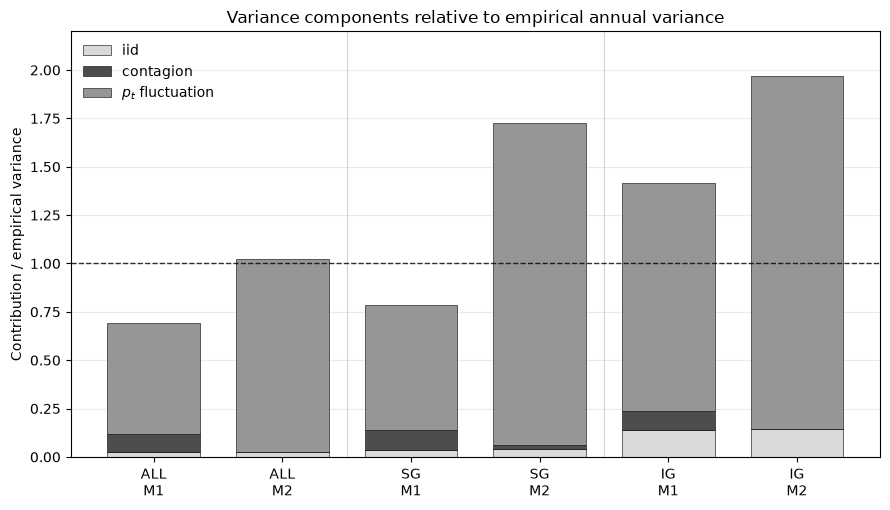

In [14]:
# ============================================================
# Final summary figure (paper style: grayscale)
#
# M1: Probit-Normal + Davis-Lo
# M2: Probit-Normal + Torri
#
# Variance components relative to empirical annual variance
#
# Reuse:
#   - out_var_pn_ld
#   - out_var_pn_torri
# ============================================================


# ------------------------------------------------------------
# 1. Build tidy comparison table
# ------------------------------------------------------------

df_cmp_decomp = build_compare_decomp_table(
    out_var_pn_ld,
    out_var_pn_torri,
)


# ------------------------------------------------------------
# 2. Prepare plotting data
# ------------------------------------------------------------

classes = [
    "ALL",
    "SG",
    "IG",
]

models = [
    "Davis–Lo",
    "Torri",
]

labels = []

iid_vals = []
inf_vals = []
pt_vals = []


for c in classes:

    for m in models:

        sub = df_cmp_decomp[
            (df_cmp_decomp["class"] == c)
            &
            (df_cmp_decomp["model"] == m)
        ]

        model_label = (
            "M1"
            if m == "Davis–Lo"
            else "M2"
        )

        labels.append(
            f"{c}\n{model_label}"
        )

        iid_vals.append(
            float(
                sub["Iid_over_VarData"].iloc[0]
            )
        )

        inf_vals.append(
            float(
                sub["Infect_over_VarData"].iloc[0]
            )
        )

        pt_vals.append(
            float(
                sub["Pt_over_VarData"].iloc[0]
            )
        )


iid_vals = np.array(
    iid_vals,
    dtype=float,
)

inf_vals = np.array(
    inf_vals,
    dtype=float,
)

pt_vals = np.array(
    pt_vals,
    dtype=float,
)


x = np.arange(
    len(labels)
)

width = 0.72


# ------------------------------------------------------------
# 3. Grayscale colors
# ------------------------------------------------------------

c_iid = "#D9D9D9"   # light gray
c_inf = "#4D4D4D"   # dark gray
c_pt  = "#969696"   # medium gray


# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.2)
)


# iid contribution
ax.bar(
    x,
    iid_vals,
    width=width,
    color=c_iid,
    edgecolor="black",
    linewidth=0.4,
    label="iid",
)


# contagion contribution
ax.bar(
    x,
    inf_vals,
    width=width,
    bottom=iid_vals,
    color=c_inf,
    edgecolor="black",
    linewidth=0.4,
    label="contagion",
)


# environmental p_t fluctuation
ax.bar(
    x,
    pt_vals,
    width=width,
    bottom=iid_vals + inf_vals,
    color=c_pt,
    edgecolor="black",
    linewidth=0.4,
    label=r"$p_t$ fluctuation",
)


# ------------------------------------------------------------
# 5. Group separators
# ------------------------------------------------------------

for pos in [
    1.5,
    3.5,
]:

    ax.axvline(
        pos,
        color="gray",
        alpha=0.35,
        linewidth=0.8,
    )


# ------------------------------------------------------------
# 6. Empirical variance reference line
# ------------------------------------------------------------

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
)


# ------------------------------------------------------------
# 7. Axes
# ------------------------------------------------------------

ax.set_xticks(
    x
)

ax.set_xticklabels(
    labels
)

ax.set_ylabel(
    "Contribution / empirical variance"
)

ax.set_title(
    "Variance components relative to empirical annual variance"
)

ax.set_ylim(
    0,
    2.2,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.set_axisbelow(
    True
)


# ------------------------------------------------------------
# 8. Legend
# ------------------------------------------------------------

ax.legend(
    frameon=False
)


# ------------------------------------------------------------
# 9. Save
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "fig_variance_decomp_hier_compare.pdf",
    bbox_inches="tight",
)

plt.show()


## 8. Tail behavior — manuscript Table IV and Fig. 3

The annual counts are rescaled to the representative fixed portfolio size for each class. Model PMFs are evaluated on the full support before VaR, ES, and survival functions are computed.

For ALL and IG, the selected M2 solution is exactly the *v = 0* boundary and therefore must coincide numerically with M0.


In [15]:
def empirical_pmf_from_counts(Ls):
    Ls = np.asarray(Ls, dtype=int)
    hmax = int(Ls.max())
    h = np.arange(hmax + 1, dtype=int)
    hist, _ = np.histogram(
        Ls,
        bins=np.arange(hmax + 2) - 0.5,
        density=True,
    )
    hist = np.maximum(hist, 0.0)
    hist = hist / hist.sum()
    return h, hist


In [16]:
# ============================================================
# Tail comparison at fixed nbar:
#
#   Data(scaled) vs M0 vs M1 vs M2
#
# M0:
#   Probit-Normal environmental null
#
# M1:
#   Probit-Normal + Davis-Lo cumulative contagion
#
# M2:
#   Probit-Normal + Torri threshold-type contagion
#
# Important:
#   For M2 boundary solutions (v = 0), M2 is exactly M0.
#   M0 and M2 PMFs are nevertheless constructed independently
#   and their numerical equality is checked explicitly.
#
# Reuse:
#   - NBAR
#   - scaled_counts(...)
#   - empirical_pmf_from_counts(...)
#   - tail_metrics_from_pmf(...)
#   - normalize_logpmf(...)
#   - gh_normal_weights(...)
#   - make_grouped_nh(...)
#   - fit_pn_null_from_grouped(...)
#   - out_all_pn_ld, out_sg_pn_ld, out_ig_pn_ld
#   - out_all_pn_torri, out_sg_pn_torri, out_ig_pn_torri
# ============================================================


# ============================================================
# 1. Canonical fit dictionaries
# ============================================================


# ------------------------------------------------------------
# M0: direct Probit-Normal null fits
# ------------------------------------------------------------

# Reuse fits_pn_m0 computed in Section 5.

# ------------------------------------------------------------
# M1: Probit-Normal + Davis-Lo
# ------------------------------------------------------------

fits_pn_ld = {
    "ALL": {
        "mu": float(out_all_pn_ld["mu"]),
        "sigma": float(out_all_pn_ld["sigma"]),
        "q": float(out_all_pn_ld["q"]),
        "GH_N": int(out_all_pn_ld["GH_N"]),
    },

    "SG": {
        "mu": float(out_sg_pn_ld["mu"]),
        "sigma": float(out_sg_pn_ld["sigma"]),
        "q": float(out_sg_pn_ld["q"]),
        "GH_N": int(out_sg_pn_ld["GH_N"]),
    },

    "IG": {
        "mu": float(out_ig_pn_ld["mu"]),
        "sigma": float(out_ig_pn_ld["sigma"]),
        "q": float(out_ig_pn_ld["q"]),
        "GH_N": int(out_ig_pn_ld["GH_N"]),
    },
}


# ------------------------------------------------------------
# M2: Probit-Normal + Torri
# ------------------------------------------------------------

fits_pn_torri = {
    "ALL": {
        "mu": float(out_all_pn_torri["mu"]),
        "sigma": float(out_all_pn_torri["sigma"]),
        "u": float(out_all_pn_torri["u"]),
        "u_eval": float(out_all_pn_torri["u_eval"]),
        "v": float(out_all_pn_torri["v"]),
        "boundary": bool(out_all_pn_torri["boundary"]),
        "GH_N": int(out_all_pn_torri["GH_N"]),
    },

    "SG": {
        "mu": float(out_sg_pn_torri["mu"]),
        "sigma": float(out_sg_pn_torri["sigma"]),
        "u": float(out_sg_pn_torri["u"]),
        "u_eval": float(out_sg_pn_torri["u_eval"]),
        "v": float(out_sg_pn_torri["v"]),
        "boundary": bool(out_sg_pn_torri["boundary"]),
        "GH_N": int(out_sg_pn_torri["GH_N"]),
    },

    "IG": {
        "mu": float(out_ig_pn_torri["mu"]),
        "sigma": float(out_ig_pn_torri["sigma"]),
        "u": float(out_ig_pn_torri["u"]),
        "u_eval": float(out_ig_pn_torri["u_eval"]),
        "v": float(out_ig_pn_torri["v"]),
        "boundary": bool(out_ig_pn_torri["boundary"]),
        "GH_N": int(out_ig_pn_torri["GH_N"]),
    },
}


# ============================================================
# 2. Fixed-n PMF helpers
# ============================================================


# ------------------------------------------------------------
# M0: Probit-Normal environmental null
# ------------------------------------------------------------

def pmf_pn_null_fixed_n(
    nbar,
    mu,
    sigma,
    GH_N,
):
    """
    PMF of M0 at fixed nbar:

        y ~ N(mu, sigma^2)
        p = Phi(y)
        L | nbar, p ~ Binomial(nbar, p)

    integrated using Gauss-Hermite quadrature.
    """

    y_nodes, w_nodes = gh_normal_weights(
        mu,
        sigma,
        GH_N,
    )

    p_nodes = np.clip(
        norm.cdf(y_nodes),
        1e-15,
        1.0 - 1e-15,
    )

    h = np.arange(
        nbar + 1,
        dtype=int,
    )

    # Binomial combinatorial term
    log_comb_vec = np.array(
        [
            math.lgamma(nbar + 1)
            - math.lgamma(int(x) + 1)
            - math.lgamma(nbar - int(x) + 1)
            for x in h
        ],
        dtype=float,
    )

    mix = np.zeros(
        nbar + 1,
        dtype=float,
    )

    for pj, wj in zip(
        p_nodes,
        w_nodes,
    ):

        log_pmf = (
            log_comb_vec
            + h * math.log(float(pj))
            + (nbar - h)
            * math.log1p(-float(pj))
        )

        pmf = normalize_logpmf(
            log_pmf
        )

        mix += (
            float(wj)
            * pmf
        )

    mix = np.maximum(
        mix,
        0.0,
    )

    mix /= mix.sum()

    return mix


# ------------------------------------------------------------
# M1: Probit-Normal + Davis-Lo
# ------------------------------------------------------------

def pmf_pn_ld_fixed_n(
    nbar,
    mu,
    sigma,
    q_param,
    GH_N,
):
    """
    PMF of M1 at fixed nbar.
    """

    y_nodes, w_nodes = gh_normal_weights(
        mu,
        sigma,
        GH_N,
    )

    p_nodes = np.clip(
        norm.cdf(y_nodes),
        1e-15,
        1.0 - 1e-15,
    )

    h = np.arange(
        nbar + 1,
        dtype=int,
    )

    mix = np.zeros(
        nbar + 1,
        dtype=float,
    )

    for pj, wj in zip(
        p_nodes,
        w_nodes,
    ):

        lp = np.array(
            [
                log_pmf_LD_1pt(
                    int(nbar),
                    int(x),
                    float(pj),
                    float(q_param),
                )
                for x in h
            ],
            dtype=float,
        )

        pmf = normalize_logpmf(
            lp
        )

        mix += (
            float(wj)
            * pmf
        )

    mix = np.maximum(
        mix,
        0.0,
    )

    mix /= mix.sum()

    return mix


# ------------------------------------------------------------
# M2: Probit-Normal + Torri
# ------------------------------------------------------------

def pmf_pn_torri_fixed_n(
    nbar,
    mu,
    sigma,
    u_eval,
    v,
    GH_N,
    boundary=False,
):
    """
    PMF of M2 at fixed nbar.

    If boundary=True, v=0 and M2 is exactly M0.
    In that case the Probit-Normal PMF is constructed
    directly rather than evaluating Torri with an
    unidentified u.
    """

    if boundary:

        return pmf_pn_null_fixed_n(
            nbar=nbar,
            mu=mu,
            sigma=sigma,
            GH_N=GH_N,
        )

    y_nodes, w_nodes = gh_normal_weights(
        mu,
        sigma,
        GH_N,
    )

    p_nodes = np.clip(
        norm.cdf(y_nodes),
        1e-15,
        1.0 - 1e-15,
    )

    h = np.arange(
        nbar + 1,
        dtype=int,
    )

    mix = np.zeros(
        nbar + 1,
        dtype=float,
    )

    for pj, wj in zip(
        p_nodes,
        w_nodes,
    ):

        lp = np.array(
            [
                log_pmf_Torri(
                    int(nbar),
                    int(x),
                    float(pj),
                    float(u_eval),
                    float(v),
                )
                for x in h
            ],
            dtype=float,
        )

        pmf = normalize_logpmf(
            lp
        )

        mix += (
            float(wj)
            * pmf
        )

    mix = np.maximum(
        mix,
        0.0,
    )

    mix /= mix.sum()

    return mix


# ============================================================
# 3. Compute tail-risk table
# ============================================================

rows = []
boundary_checks = []


for key in (
    "ALL",
    "SG",
    "IG",
):

    nbar = int(
        NBAR[key]
    )

    # --------------------------------------------------------
    # Data: fixed-nbar scaled empirical distribution
    # --------------------------------------------------------

    n_vals, L_vals = _clean_nL(
        df,
        key,
    )

    L_scaled = scaled_counts(
        n_vals,
        L_vals,
        nbar,
    )

    _, pmf_data = empirical_pmf_from_counts(
        L_scaled
    )

    pmf_data_full = np.zeros(
        nbar + 1,
        dtype=float,
    )

    pmf_data_full[
        :len(pmf_data)
    ] = pmf_data


    # --------------------------------------------------------
    # M0: direct Probit-Normal
    # --------------------------------------------------------

    pmf_m0 = pmf_pn_null_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_m0[key]["mu"]
        ),
        sigma=float(
            fits_pn_m0[key]["sigma"]
        ),
        GH_N=int(
            fits_pn_m0[key]["GH_N"]
        ),
    )


    # --------------------------------------------------------
    # M1: Probit-Normal + Davis-Lo
    # --------------------------------------------------------

    pmf_m1 = pmf_pn_ld_fixed_n(
        nbar=nbar,
        mu=fits_pn_ld[key]["mu"],
        sigma=fits_pn_ld[key]["sigma"],
        q_param=fits_pn_ld[key]["q"],
        GH_N=fits_pn_ld[key]["GH_N"],
    )


    # --------------------------------------------------------
    # M2: Probit-Normal + Torri
    # --------------------------------------------------------

    pmf_m2 = pmf_pn_torri_fixed_n(
        nbar=nbar,
        mu=fits_pn_torri[key]["mu"],
        sigma=fits_pn_torri[key]["sigma"],
        u_eval=fits_pn_torri[key]["u_eval"],
        v=fits_pn_torri[key]["v"],
        GH_N=fits_pn_torri[key]["GH_N"],
        boundary=fits_pn_torri[key]["boundary"],
    )


    # --------------------------------------------------------
    # Boundary verification:
    #
    # ALL and IG should satisfy M2 == M0 numerically.
    # --------------------------------------------------------

    if fits_pn_torri[key]["boundary"]:

        max_abs_diff = float(
            np.max(
                np.abs(
                    pmf_m2
                    - pmf_m0
                )
            )
        )

        l1_diff = float(
            np.sum(
                np.abs(
                    pmf_m2
                    - pmf_m0
                )
            )
        )

        boundary_checks.append(
            {
                "class": key,
                "max_abs_pmf_diff_M0_M2": max_abs_diff,
                "L1_pmf_diff_M0_M2": l1_diff,
            }
        )

        assert max_abs_diff < 1e-8, (
            f"{key}: M2 boundary PMF does not match M0. "
            f"max abs diff = {max_abs_diff}"
        )


    # --------------------------------------------------------
    # Tail metrics
    # --------------------------------------------------------

    for alpha in (
        0.95,
        0.99,
    ):

        for model_name, pmf in (
            ("Data(scaled)", pmf_data_full),
            ("M0", pmf_m0),
            ("M1", pmf_m1),
            ("M2", pmf_m2),
        ):

            met = tail_metrics_from_pmf(
                pmf,
                alpha=alpha,
                strict_es=False,
            )

            rows.append(
                {
                    "class": key,
                    "alpha": alpha,
                    "model": model_name,
                    "VaR": met["VaR"],
                    "ES": met["ES"],
                    "ES_minus_VaR": met[
                        "ES_minus_VaR"
                    ],
                    "ES_over_VaR": met[
                        "ES_over_VaR"
                    ],
                }
            )


# ============================================================
# 4. Final tables
# ============================================================

df_tail_pn = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "class",
            "alpha",
            "model",
        ]
    )
    .reset_index(
        drop=True
    )
)


df_boundary_check = pd.DataFrame(
    boundary_checks
)


print(
    "Boundary PMF checks "
    "(M0 vs M2):"
)

display(
    df_boundary_check
)


print(
    "Tail-risk comparison:"
)

display(
    df_tail_pn
)

df_tail_pn.to_csv(
    PDATA_DIR / "table_iv_environmental_tail_risk_long.csv",
    index=False,
)

if DATA_SOURCE == "REAL":
    expected_tail = {
        ("ALL", 0.95, "Data(scaled)"): (91, 124.1),
        ("ALL", 0.95, "M1"): (87, 117.4),
        ("ALL", 0.95, "M2"): (97, 141.4),
        ("ALL", 0.95, "M0"): (97, 141.4),
        ("ALL", 0.99, "Data(scaled)"): (141, 180.0),
        ("ALL", 0.99, "M1"): (136, 169.7),
        ("ALL", 0.99, "M2"): (170, 220.9),
        ("ALL", 0.99, "M0"): (170, 220.9),

        ("SG", 0.95, "Data(scaled)"): (92, 113.7),
        ("SG", 0.95, "M1"): (81, 106.1),
        ("SG", 0.95, "M2"): (113, 159.3),
        ("SG", 0.95, "M0"): (91, 125.5),
        ("SG", 0.99, "Data(scaled)"): (122, 140.5),
        ("SG", 0.99, "M1"): (123, 149.2),
        ("SG", 0.99, "M2"): (190, 239.2),
        ("SG", 0.99, "M0"): (148, 184.3),

        ("IG", 0.95, "Data(scaled)"): (10, 15.0),
        ("IG", 0.95, "M1"): (10, 17.4),
        ("IG", 0.95, "M2"): (11, 20.7),
        ("IG", 0.95, "M0"): (11, 20.7),
        ("IG", 0.99, "Data(scaled)"): (20, 22.0),
        ("IG", 0.99, "M1"): (23, 34.2),
        ("IG", 0.99, "M2"): (27, 42.1),
        ("IG", 0.99, "M0"): (27, 42.1),
    }

    max_var_diff = 0
    max_es_diff = 0.0

    for (key, alpha, model), (var_exp, es_exp) in expected_tail.items():
        row = df_tail_pn[
            (df_tail_pn["class"] == key)
            & (df_tail_pn["alpha"] == alpha)
            & (df_tail_pn["model"] == model)
        ].iloc[0]

        max_var_diff = max(
            max_var_diff,
            abs(int(row["VaR"]) - int(var_exp))
        )
        max_es_diff = max(
            max_es_diff,
            abs(round(float(row["ES"]), 1) - float(es_exp))
        )

    print(f"Maximum VaR difference from Table IV: {max_var_diff}")
    print(f"Maximum ES difference after 1-decimal rounding: {max_es_diff:.6g}")
    print(
        "Table IV audit:",
        "PASS" if (max_var_diff == 0 and max_es_diff < 5e-4) else "REVIEW"
    )

else:
    print("Manuscript-value audit skipped for synthetic data.")

print(f"Saved: {PDATA_DIR / 'table_iv_environmental_tail_risk_long.csv'}")


Boundary PMF checks (M0 vs M2):


,class,max_abs_pmf_diff_M0_M2,L1_pmf_diff_M0_M2
0,ALL,0,0
1,IG,0,0


Tail-risk comparison:


,class,alpha,model,VaR,ES,ES_minus_VaR,ES_over_VaR
0,ALL,0.95,Data(scaled),91,124.143,33.1429,1.36421
1,ALL,0.95,M0,97,141.381,44.3813,1.45754
2,ALL,0.95,M1,87,117.393,30.3933,1.34935
3,ALL,0.95,M2,97,141.381,44.3813,1.45754
4,ALL,0.99,Data(scaled),141,180,39,1.2766
5,ALL,0.99,M0,170,220.862,50.862,1.29919
6,ALL,0.99,M1,136,169.716,33.7164,1.24791
7,ALL,0.99,M2,170,220.862,50.862,1.29919
8,IG,0.95,Data(scaled),10,15,5,1.5
9,IG,0.95,M0,11,20.7395,9.7395,1.88541


Maximum VaR difference from Table IV: 0
Maximum ES difference after 1-decimal rounding: 0
Table IV audit: PASS
Saved: ./pdata/table_iv_environmental_tail_risk_long.csv


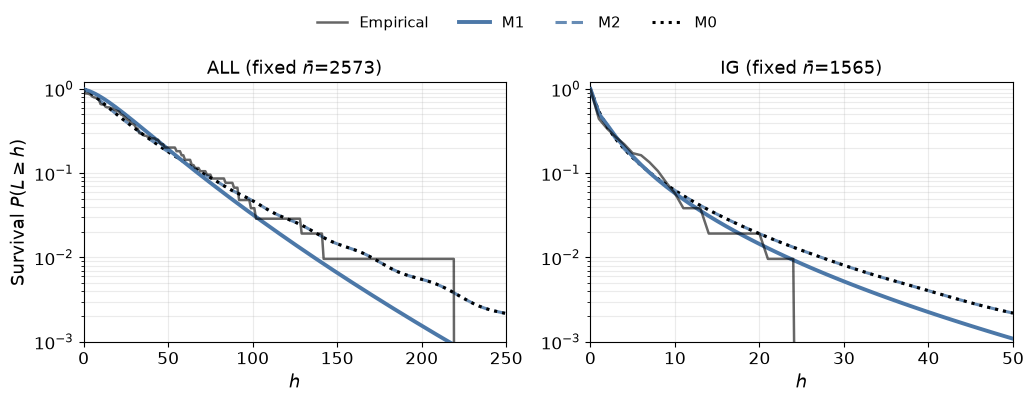

In [17]:
# ============================================================
# Survival functions at fixed nbar:
#
#   Empirical vs M0 vs M1 vs M2
#
# M0:
#   Probit-Normal environmental null
#
# M1:
#   Probit-Normal + Davis-Lo cumulative contagion
#
# M2:
#   Probit-Normal + Torri threshold-type contagion
#
# Important:
#   - Model PMFs are computed on the full support 0,...,nbar.
#   - Plotting range is controlled only by HMAX_MAP / XLIM_MAP.
#   - For ALL and IG, M2 is the exact v=0 boundary and
#     therefore coincides with M0.
#
# Reuse:
#   - NBAR
#   - scaled_counts(...)
#   - survival_from_pmf(...)
#   - pmf_pn_null_fixed_n(...)
#   - pmf_pn_ld_fixed_n(...)
#   - pmf_pn_torri_fixed_n(...)
#   - fits_pn_m0
#   - fits_pn_ld
#   - fits_pn_torri
# ============================================================


mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})


# ------------------------------------------------------------
# Fixed portfolio sizes
# ------------------------------------------------------------

NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}


# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------

style = {

    "Empirical": {
        "color": "black",
        "ls": "-",
        "lw": 1.8,
        "alpha": 0.60,
        "zorder": 4,
    },

    "M1": {
        "color": "#4C78A8",
        "ls": "-",
        "lw": 2.8,
        "zorder": 3,
    },

    # Draw M2 before M0.
    # For ALL and IG the curves coincide exactly.
    "M2": {
        "color": "#4C78A8",
        "ls": "--",
        "lw": 2.2,
        "alpha": 0.85,
        "zorder": 1,
    },

    "M0": {
        "color": "black",
        "ls": ":",
        "lw": 2.2,
        "zorder": 2,
    },
}


# ------------------------------------------------------------
# Display range by class
# ------------------------------------------------------------

HMAX_MAP = {
    "ALL": 250,
    "SG":  130,
    "IG":   50,
}

XLIM_MAP = {
    "ALL": (0, 250),
    "SG":  (0, 130),
    "IG":  (0, 50),
}

YLIM_MAP = {
    "ALL": (1e-3, 1.2),
    "SG":  (1e-3, 1.2),
    "IG":  (1e-3, 1.2),
}


# ============================================================
# Plot helper
# ============================================================

def plot_survival_m012_one(
    ax,
    key,
):
    """
    Plot empirical and M0/M1/M2 survival functions
    at fixed representative exposure nbar.
    """

    nbar = int(
        NBAR[key]
    )

    hmax_plot = int(
        HMAX_MAP[key]
    )


    # --------------------------------------------------------
    # Empirical scaled distribution
    # --------------------------------------------------------

    n_vals, L_vals = _clean_nL(
        df,
        key,
    )

    L_scaled = scaled_counts(
        n_vals,
        L_vals,
        nbar,
    )

    # Full support 0,...,nbar.
    pmf_data = np.bincount(
        L_scaled,
        minlength=nbar + 1,
    ).astype(float)

    pmf_data /= pmf_data.sum()


    # --------------------------------------------------------
    # M0: Probit-Normal environmental null
    # --------------------------------------------------------

    pmf_m0 = pmf_pn_null_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_m0[key]["mu"]
        ),
        sigma=float(
            fits_pn_m0[key]["sigma"]
        ),
        GH_N=int(
            fits_pn_m0[key]["GH_N"]
        ),
    )


    # --------------------------------------------------------
    # M1: Probit-Normal + Davis-Lo
    # --------------------------------------------------------

    pmf_m1 = pmf_pn_ld_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_ld[key]["mu"]
        ),
        sigma=float(
            fits_pn_ld[key]["sigma"]
        ),
        q_param=float(
            fits_pn_ld[key]["q"]
        ),
        GH_N=int(
            fits_pn_ld[key]["GH_N"]
        ),
    )


    # --------------------------------------------------------
    # M2: Probit-Normal + Torri
    # --------------------------------------------------------

    pmf_m2 = pmf_pn_torri_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_torri[key]["mu"]
        ),
        sigma=float(
            fits_pn_torri[key]["sigma"]
        ),
        u_eval=float(
            fits_pn_torri[key]["u_eval"]
        ),
        v=float(
            fits_pn_torri[key]["v"]
        ),
        GH_N=int(
            fits_pn_torri[key]["GH_N"]
        ),
        boundary=bool(
            fits_pn_torri[key]["boundary"]
        ),
    )


    # --------------------------------------------------------
    # Boundary consistency:
    # ALL and IG should have M2 == M0.
    # --------------------------------------------------------

    if fits_pn_torri[key]["boundary"]:

        max_abs_diff = float(
            np.max(
                np.abs(
                    pmf_m2
                    - pmf_m0
                )
            )
        )

        assert max_abs_diff < 1e-8, (
            f"{key}: boundary M2 does not match M0; "
            f"max PMF difference = {max_abs_diff}"
        )


    # --------------------------------------------------------
    # Survival functions on full support
    # --------------------------------------------------------

    S_data = survival_from_pmf(
        pmf_data
    )

    S_m0 = survival_from_pmf(
        pmf_m0
    )

    S_m1 = survival_from_pmf(
        pmf_m1
    )

    S_m2 = survival_from_pmf(
        pmf_m2
    )


    # --------------------------------------------------------
    # Plot only the required horizontal range
    # --------------------------------------------------------

    h = np.arange(
        hmax_plot + 1,
        dtype=int,
    )

    eps = 1e-12


    ax.plot(
        h,
        np.maximum(
            S_data[:hmax_plot + 1],
            eps,
        ),
        label="Empirical",
        **style["Empirical"],
    )


    # M2 first.
    # For ALL/IG M0 will be drawn on the same curve afterward.
    ax.plot(
        h,
        np.maximum(
            S_m2[:hmax_plot + 1],
            eps,
        ),
        label="M2",
        **style["M2"],
    )


    ax.plot(
        h,
        np.maximum(
            S_m1[:hmax_plot + 1],
            eps,
        ),
        label="M1",
        **style["M1"],
    )


    ax.plot(
        h,
        np.maximum(
            S_m0[:hmax_plot + 1],
            eps,
        ),
        label="M0",
        **style["M0"],
    )


    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_yscale(
        "log"
    )

    ax.set_title(
        f"{key} (fixed $\\bar{{n}}$={nbar})"
    )

    ax.set_xlabel(
        r"$h$"
    )

    ax.set_ylabel(
        r"Survival $P(L \geq h)$"
    )

    ax.grid(
        alpha=0.25,
        which="both",
    )

    ax.set_xlim(
        *XLIM_MAP[key]
    )

    ax.set_ylim(
        *YLIM_MAP[key]
    )


# ============================================================
# Figure: survival functions for ALL and IG
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4),
)


for ax, key in zip(
    axes,
    [
        "ALL",
        "IG",
    ],
):

    plot_survival_m012_one(
        ax,
        key,
    )


# Keep y-label on the left panel only.
axes[1].set_ylabel(
    ""
)


# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)


order = [
    "Empirical",
    "M1",
    "M2",
    "M0",
]


handles_dict = dict(
    zip(
        labels,
        handles,
    )
)


ordered_handles = [
    handles_dict[label]
    for label in order
    if label in handles_dict
]


ordered_labels = [
    label
    for label in order
    if label in handles_dict
]


fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(
        0.5,
        1.02,
    ),
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.92,
    ]
)


# Keep the existing filename so manuscript references
# do not have to be changed at this stage.
plt.savefig(
    FIGURE_DIR
    / "fig_survival_hierarchical_ALL_IG.pdf",
    bbox_inches="tight",
)


plt.show()


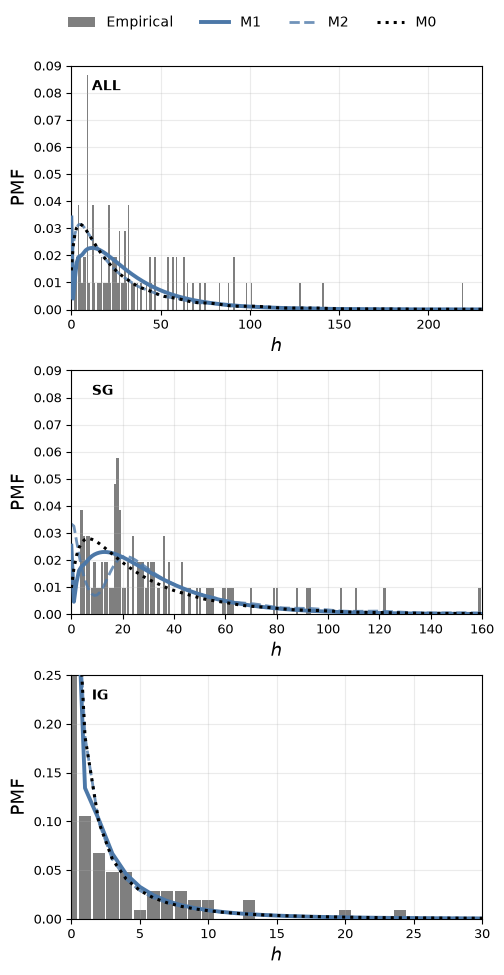

In [18]:
# ==========================================
# PMF: Empirical vs M0 vs M1 vs M2
#
# M0: Probit-Normal environmental null
# M1: Probit-Normal + Davis-Lo
# M2: Probit-Normal + Torri
#
# ALL + SG + IG
#
# Important:
#   - PMFs are computed on the full support 0,...,nbar.
#   - Plotting range is controlled only by HMAX_MAP / XLIM_MAP.
#   - For ALL and IG, M2 is the exact v=0 boundary
#     and therefore coincides with M0.
# ==========================================


mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})


NBAR = {
    "ALL": 2573,
    "SG":  1008,
    "IG":  1565,
}


# ------------------------------------------------------------
# Plot range
# ------------------------------------------------------------

HMAX_MAP = {
    "ALL": 300,
    "SG":  300,
    "IG":   40,
}

XLIM_MAP = {
    "ALL": (0, 230),
    "SG":  (0, 160),
    "IG":  (0, 30),
}

YLIM_MAP = {
    "ALL": (0, 0.09),
    "SG":  (0, 0.09),
    "IG":  (0, 0.25),
}


# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------

style = {

    "Empirical": {
        "color": "black",
        "alpha": 0.5,
    },

    "M1": {
        "color": "#4C78A8",
        "lw": 2.8,
        "ls": "-",
    },

    # Draw M2 before M0 so that exact overlap
    # for ALL/IG remains identifiable.
    "M2": {
        "color": "#4C78A8",
        "lw": 2.0,
        "ls": "--",
        "alpha": 0.8,
    },

    "M0": {
        "color": "black",
        "lw": 2.2,
        "ls": ":",
    },
}


# ============================================================
# PMF plot helper
# ============================================================

def plot_pmf_m012_one(
    ax,
    key,
    show_legend=True,
):
    """
    Plot empirical and M0/M1/M2 PMFs
    at fixed representative exposure nbar.
    """

    nbar = int(
        NBAR[key]
    )

    hmax_plot = int(
        HMAX_MAP[key]
    )

    h = np.arange(
        hmax_plot + 1,
        dtype=int,
    )


    # --------------------------------------------------------
    # Empirical scaled data
    # --------------------------------------------------------

    n_vals, L_vals = _clean_nL(
        df,
        key,
    )

    L_scaled = scaled_counts(
        n_vals,
        L_vals,
        nbar,
    )

    # Full empirical support 0,...,nbar
    pmf_data_full = np.bincount(
        L_scaled,
        minlength=nbar + 1,
    ).astype(float)

    pmf_data_full /= (
        pmf_data_full.sum()
    )

    pmf_data = (
        pmf_data_full[
            :hmax_plot + 1
        ]
    )


    # --------------------------------------------------------
    # M0: Probit-Normal environmental null
    # --------------------------------------------------------

    pmf_m0_full = pmf_pn_null_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_m0[key]["mu"]
        ),
        sigma=float(
            fits_pn_m0[key]["sigma"]
        ),
        GH_N=int(
            fits_pn_m0[key]["GH_N"]
        ),
    )


    # --------------------------------------------------------
    # M1: Probit-Normal + Davis-Lo
    # --------------------------------------------------------

    pmf_m1_full = pmf_pn_ld_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_ld[key]["mu"]
        ),
        sigma=float(
            fits_pn_ld[key]["sigma"]
        ),
        q_param=float(
            fits_pn_ld[key]["q"]
        ),
        GH_N=int(
            fits_pn_ld[key]["GH_N"]
        ),
    )


    # --------------------------------------------------------
    # M2: Probit-Normal + Torri
    # --------------------------------------------------------

    pmf_m2_full = pmf_pn_torri_fixed_n(
        nbar=nbar,
        mu=float(
            fits_pn_torri[key]["mu"]
        ),
        sigma=float(
            fits_pn_torri[key]["sigma"]
        ),
        u_eval=float(
            fits_pn_torri[key]["u_eval"]
        ),
        v=float(
            fits_pn_torri[key]["v"]
        ),
        GH_N=int(
            fits_pn_torri[key]["GH_N"]
        ),
        boundary=bool(
            fits_pn_torri[key]["boundary"]
        ),
    )


    # --------------------------------------------------------
    # Boundary consistency:
    # ALL and IG must satisfy M2 == M0.
    # --------------------------------------------------------

    if fits_pn_torri[key]["boundary"]:

        max_abs_diff = float(
            np.max(
                np.abs(
                    pmf_m2_full
                    - pmf_m0_full
                )
            )
        )

        assert max_abs_diff < 1e-8, (
            f"{key}: boundary M2 does not match M0; "
            f"max PMF difference = {max_abs_diff}"
        )


    # --------------------------------------------------------
    # Restrict only for plotting
    # --------------------------------------------------------

    pmf_m0 = (
        pmf_m0_full[
            :hmax_plot + 1
        ]
    )

    pmf_m1 = (
        pmf_m1_full[
            :hmax_plot + 1
        ]
    )

    pmf_m2 = (
        pmf_m2_full[
            :hmax_plot + 1
        ]
    )


    # --------------------------------------------------------
    # Plot empirical histogram
    # --------------------------------------------------------

    ax.bar(
        h,
        pmf_data,
        width=0.9,
        label="Empirical",
        zorder=1,
        **style["Empirical"],
    )


    # --------------------------------------------------------
    # Plot model PMFs
    # --------------------------------------------------------

    ax.plot(
        h,
        pmf_m2,
        label="M2",
        zorder=2,
        **style["M2"],
    )

    ax.plot(
        h,
        pmf_m1,
        label="M1",
        zorder=3,
        **style["M1"],
    )

    # M0 last:
    # for ALL/IG it lies exactly on top of M2.
    ax.plot(
        h,
        pmf_m0,
        label="M0",
        zorder=4,
        **style["M0"],
    )


    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_title(
        f"{key} (fixed $\\bar{{n}}$={nbar})"
    )

    ax.set_xlabel(
        r"$h$"
    )

    ax.set_ylabel(
        "PMF"
    )

    ax.grid(
        alpha=0.25
    )

    ax.set_xlim(
        *XLIM_MAP[key]
    )

    ax.set_ylim(
        *YLIM_MAP[key]
    )


    if show_legend:

        ax.legend(
            frameon=False
        )


# ============================================================
# PMF: ALL + SG + IG (stacked)
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(5.2, 10),
)


labels_map = {
    "ALL": "ALL",
    "SG":  "SG",
    "IG":  "IG",
}


for ax, key in zip(
    axes,
    [
        "ALL",
        "SG",
        "IG",
    ],
):

    plot_pmf_m012_one(
        ax,
        key,
        show_legend=False,
    )


    # Remove panel title;
    # use in-panel class label instead.
    ax.set_title(
        ""
    )


    ax.text(
        0.05,
        0.90,
        labels_map[key],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
    )


    ax.tick_params(
        labelsize=9
    )


# ============================================================
# Shared legend
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)


order = [
    "Empirical",
    "M1",
    "M2",
    "M0",
]


handles_dict = dict(
    zip(
        labels,
        handles,
    )
)


ordered_handles = [
    handles_dict[label]
    for label in order
    if label in handles_dict
]


ordered_labels = [
    label
    for label in order
    if label in handles_dict
]


fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(
        0.5,
        0.98,
    ),
    fontsize=10,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


plt.subplots_adjust(
    hspace=0.25
)


plt.savefig(
    FIGURE_DIR
    / "fig_pmf_hier_ALLCLASS.pdf",
    bbox_inches="tight",
)


plt.show()


## 9. Directed KL separation among the fitted M0–M2 distributions — manuscript Table VIII

The fitted parameters are held fixed at their best-found values.

For each credit class, directed KL divergences are averaged over the **actually observed annual portfolio sizes** *n_t*. Because KL divergence is asymmetric, both directions are retained.

This is a descriptive measure of distributional separation among the fitted models; it is not used as an additional model-selection criterion.

**Runtime note:** this section is substantially heavier than the preceding cells because it constructs full-support predictive PMFs for many distinct annual portfolio sizes.


In [19]:
# ============================================================
# Appendix D.2
# Distributional separation among fitted M0, M1, and M2
#
# Mean directed KL divergence over the actually observed n_t:
#
#   D_ab = (1/T) sum_t KL[ P_a(. | n_t) || P_b(. | n_t) ]
#
# Models:
#
#   M0 = Probit-Normal environmental null
#
#   M1 = Probit-Normal
#        + Davis-Lo cumulative contagion
#
#   M2 = Probit-Normal
#        + Torri threshold-type contagion
#
# Important:
#
#   If the fitted M2 solution is on the exact v=0 boundary,
#
#       M2 == M0
#
#   and u is unidentified.
#
#   Boundary status is read directly from fits_pn_torri;
#   it is not hard-coded by class.
#
# No refitting is performed in this cell.
# ============================================================


import time
import warnings

from scipy.stats import binom
# from scipy.special import gammaln, logsumexp
from scipy.special import gammaln, logsumexp as scipy_logsumexp

# ============================================================
# Numerical settings
# ============================================================

# Sparse-tail truncation is used only to accelerate
# conditional Davis-Lo full-PMF calculations.
LD_TAIL_TOL = 1e-12

# GH nodes with extremely small weights are skipped
# only for the M1 calculation.
GH_WEIGHT_TOL = 1e-14

# Numerical floor used only inside log(Q) for KL.
KL_FLOOR = 1e-300


# ============================================================
# 1. Fast full-support conditional Davis-Lo PMF
# ============================================================

def pmf_ld_sparse_full(
    n,
    p,
    q,
    tail_tol=LD_TAIL_TOL,
):
    """
    Full-support Davis-Lo PMF on h=0,...,n.

    Only numerically negligible tails of the internal
    Binomial distributions are truncated for speed.

    The returned PMF always has length n+1.
    """

    n = int(n)

    p = float(
        np.clip(
            p,
            1e-15,
            1.0 - 1e-15,
        )
    )

    q = float(
        np.clip(
            q,
            0.0,
            1.0,
        )
    )


    pmf = np.zeros(
        n + 1,
        dtype=float,
    )


    qt = tail_tol / 2.0


    # --------------------------------------------------------
    # Relevant support of seed defaults
    #
    #   K ~ Binomial(n,p)
    # --------------------------------------------------------

    k_lo = int(
        max(
            0,
            math.floor(
                float(
                    binom.ppf(
                        qt,
                        n,
                        p,
                    )
                )
            ),
        )
    )


    k_hi = int(
        min(
            n,
            math.ceil(
                float(
                    binom.ppf(
                        1.0 - qt,
                        n,
                        p,
                    )
                )
            ),
        )
    )


    ks = np.arange(
        k_lo,
        k_hi + 1,
        dtype=int,
    )


    pk = binom.pmf(
        ks,
        n,
        p,
    )


    if q == 1.0:

        log1mq = -np.inf

    else:

        log1mq = math.log1p(
            -q
        )


    for k, wk in zip(
        ks,
        pk,
    ):

        if wk <= 0.0:
            continue


        k = int(k)

        nk = n - k


        # ----------------------------------------------------
        # No seed default or no contagion
        # ----------------------------------------------------

        if (
            k == 0
            or q == 0.0
        ):

            pmf[k] += wk
            continue


        # ----------------------------------------------------
        # q=1: all surviving names are infected
        # ----------------------------------------------------

        if q == 1.0:

            pmf[n] += wk
            continue


        # ----------------------------------------------------
        # Additional-default probability
        #
        #   r_k = 1 - (1-q)^k
        # ----------------------------------------------------

        rk = -math.expm1(
            k * log1mq
        )


        if rk <= 0.0:

            pmf[k] += wk
            continue


        if rk >= 1.0:

            pmf[n] += wk
            continue


        # ----------------------------------------------------
        # Relevant support of additional infections
        # ----------------------------------------------------

        t_lo = int(
            max(
                0,
                math.floor(
                    float(
                        binom.ppf(
                            qt,
                            nk,
                            rk,
                        )
                    )
                ),
            )
        )


        t_hi = int(
            min(
                nk,
                math.ceil(
                    float(
                        binom.ppf(
                            1.0 - qt,
                            nk,
                            rk,
                        )
                    )
                ),
            )
        )


        ts = np.arange(
            t_lo,
            t_hi + 1,
            dtype=int,
        )


        pmf[
            k + ts
        ] += (
            wk
            * binom.pmf(
                ts,
                nk,
                rk,
            )
        )


    return pmf


# ============================================================
# 2. Full M1 predictive PMF
# ============================================================

def pmf_m1_full(
    n,
    fit,
):
    """
    M1 predictive PMF:

        Probit-Normal mixing
        + Davis-Lo contagion.
    """

    n = int(n)


    mu = float(
        fit["mu"]
    )

    sigma = float(
        fit["sigma"]
    )

    q = float(
        fit["q"]
    )

    GH_N = int(
        fit["GH_N"]
    )


    y_nodes, w_nodes = gh_normal_weights(
        mu,
        sigma,
        GH_N,
    )


    pmf = np.zeros(
        n + 1,
        dtype=float,
    )


    skipped_gh_mass = 0.0


    for yj, wj in zip(
        y_nodes,
        w_nodes,
    ):

        wj = float(wj)


        if wj < GH_WEIGHT_TOL:

            skipped_gh_mass += wj
            continue


        pj = float(
            norm.cdf(yj)
        )


        pj = float(
            np.clip(
                pj,
                1e-15,
                1.0 - 1e-15,
            )
        )


        pmf_cond = pmf_ld_sparse_full(
            n=n,
            p=pj,
            q=q,
            tail_tol=LD_TAIL_TOL,
        )


        pmf += (
            wj
            * pmf_cond
        )


    raw_mass = float(
        pmf.sum()
    )


    if raw_mass <= 0.0:

        raise RuntimeError(
            f"M1 PMF has zero mass for n={n}"
        )


    mass_defect = (
        1.0
        - raw_mass
    )


    pmf /= raw_mass


    return (
        pmf,
        mass_defect,
        skipped_gh_mass,
    )


# ============================================================
# 3. Vectorized Torri conditional log-PMF
# ============================================================

def log_pmf_torri_full_vec(
    n,
    p,
    u,
    v,
):
    """
    Vectorized Torri log-PMF on h=0,...,n.
    """

    n = int(n)


    p = float(
        np.clip(
            p,
            1e-15,
            1.0 - 1e-15,
        )
    )


    u = float(
        np.clip(
            u,
            0.0,
            1.0,
        )
    )


    v = float(
        np.clip(
            v,
            0.0,
            1.0,
        )
    )


    h = np.arange(
        n + 1,
        dtype=float,
    )


    logC = (
        gammaln(n + 1)
        - gammaln(h + 1)
        - gammaln(n - h + 1)
    )


    a = p * (
        1.0 - v
    )

    b = (
        1.0 - p
    ) * (
        1.0 - u
    )

    c = (
        1.0 - p
    ) * u

    bc = (
        1.0 - p
    )


    # --------------------------------------------------------
    # Term 0
    # --------------------------------------------------------

    t0 = np.full(
        n + 1,
        -np.inf,
        dtype=float,
    )


    if a > 0.0:

        t0 = (
            h * math.log(a)
            + (n - h)
            * math.log(bc)
        )

    else:

        t0[0] = (
            n
            * math.log(bc)
        )


    # --------------------------------------------------------
    # Term 1
    # --------------------------------------------------------

    t1 = np.full(
        n + 1,
        -np.inf,
        dtype=float,
    )


    pb = p + b

    ab = a + b


    mask = (
        h > 0
    )


    if (
        pb > 0.0
        and ab > 0.0
    ):

        hh = h[
            mask
        ]


        lp = (
            hh
            * math.log(pb)
        )


        la = (
            hh
            * math.log(ab)
        )


        logdiff = np.full_like(
            lp,
            -np.inf,
            dtype=float,
        )


        good = (
            lp > la
        )


        logdiff[
            good
        ] = (
            lp[good]
            + np.log1p(
                -np.exp(
                    la[good]
                    - lp[good]
                )
            )
        )


        exponent_c = (
            n - hh
        )


        log_c_pow = np.full_like(
            hh,
            -np.inf,
            dtype=float,
        )


        zero_power = (
            exponent_c == 0
        )


        log_c_pow[
            zero_power
        ] = 0.0


        if c > 0.0:

            log_c_pow[
                ~zero_power
            ] = (
                exponent_c[
                    ~zero_power
                ]
                * math.log(c)
            )


        t1[
            mask
        ] = (
            logdiff
            + log_c_pow
        )


    return (
        logC
        + np.logaddexp(
            t0,
            t1,
        )
    )


# ============================================================
# 4. Full M2 predictive PMF
# ============================================================

def pmf_m2_full(
    n,
    fit,
):
    """
    M2 predictive PMF.

    For an interior M2 solution:
        Probit-Normal mixing + Torri contagion.

    Boundary v=0 is handled outside this function
    by directly using M0.
    """

    n = int(n)


    mu = float(
        fit["mu"]
    )

    sigma = float(
        fit["sigma"]
    )

    # Only meaningful for interior M2.
    u = float(
        fit["u_eval"]
    )

    v = float(
        fit["v"]
    )

    GH_N = int(
        fit["GH_N"]
    )


    y_nodes, w_nodes = gh_normal_weights(
        mu,
        sigma,
        GH_N,
    )


    log_terms = []


    for yj, wj in zip(
        y_nodes,
        w_nodes,
    ):

        pj = float(
            norm.cdf(yj)
        )


        pj = float(
            np.clip(
                pj,
                1e-15,
                1.0 - 1e-15,
            )
        )


        lp = log_pmf_torri_full_vec(
            n=n,
            p=pj,
            u=u,
            v=v,
        )


        log_terms.append(
            math.log(
                float(wj)
            )
            + lp
        )


    log_terms = np.vstack(
        log_terms
    )


    log_mix = scipy_logsumexp(
        log_terms,
        axis=0,
    )


    log_mix -= scipy_logsumexp(
        log_mix
    )


    return np.exp(
        log_mix
    )


# ============================================================
# 5. Full M0 predictive PMF
# ============================================================

def pmf_m0_full(
    n,
    key,
):
    """
    M0 predictive PMF:

        y_t ~ N(mu, sigma^2)
        p_t = Phi(y_t)
        L_t | n_t,p_t ~ Binomial(n_t,p_t)

    Uses the directly fitted Probit-Normal M0 parameters.
    """

    fit = fits_pn_m0[
        key
    ]


    return pmf_pn_null_fixed_n(
        nbar=int(n),
        mu=float(
            fit["mu"]
        ),
        sigma=float(
            fit["sigma"]
        ),
        GH_N=int(
            fit["GH_N"]
        ),
    )


# ============================================================
# 6. Directed KL divergence
# ============================================================

def directed_kl(
    P,
    Q,
    floor=KL_FLOOR,
):
    """
    KL(P || Q).

    P and Q must have identical support.
    """

    P = np.asarray(
        P,
        dtype=float,
    )

    Q = np.asarray(
        Q,
        dtype=float,
    )


    if P.shape != Q.shape:

        raise ValueError(
            "P and Q must have identical support."
        )


    mask = (
        P > 0.0
    )


    if not np.any(
        mask
    ):

        return np.nan


    q_safe = np.maximum(
        Q[mask],
        floor,
    )


    return float(
        np.sum(
            P[mask]
            * (
                np.log(
                    P[mask]
                )
                - np.log(
                    q_safe
                )
            )
        )
    )


# ============================================================
# 7. Mean KL over actually observed n_t
# ============================================================

def mean_kl_for_class(
    key,
):

    # --------------------------------------------------------
    # Only observed portfolio sizes matter here.
    # --------------------------------------------------------

    n_vals = pd.to_numeric(
        df[key],
        errors="coerce",
    ).to_numpy()


    mask = (
        np.isfinite(
            n_vals
        )
        &
        (
            n_vals > 0
        )
    )


    n_vals = (
        n_vals[
            mask
        ]
        .astype(int)
    )


    unique_n, counts = np.unique(
        n_vals,
        return_counts=True,
    )


    T_obs = int(
        counts.sum()
    )


    models = [
        "M0",
        "M1",
        "M2",
    ]


    kl_sum = {
        (
            a,
            b,
        ): 0.0

        for a in models
        for b in models
    }


    diagnostics = []


    t0 = time.time()


    # --------------------------------------------------------
    # Canonical fitted states
    # --------------------------------------------------------

    fit_m1 = fits_pn_ld[
        key
    ]


    fit_m2 = fits_pn_torri[
        key
    ]


    m2_boundary = bool(
        fit_m2[
            "boundary"
        ]
    )


    for idx, (
        n,
        count,
    ) in enumerate(
        zip(
            unique_n,
            counts,
        ),
        start=1,
    ):

        n = int(n)

        count = int(count)


        # ----------------------------------------------------
        # M0
        # ----------------------------------------------------

        P0 = pmf_m0_full(
            n=n,
            key=key,
        )


        # ----------------------------------------------------
        # M1
        # ----------------------------------------------------

        (
            P1,
            mass_defect_m1,
            skipped_gh,
        ) = pmf_m1_full(
            n=n,
            fit=fit_m1,
        )


        # ----------------------------------------------------
        # M2
        # ----------------------------------------------------

        if m2_boundary:

            # Exact theoretical identity at v=0.
            P2 = P0.copy()

        else:

            P2 = pmf_m2_full(
                n=n,
                fit=fit_m2,
            )


        P = {
            "M0": P0,
            "M1": P1,
            "M2": P2,
        }


        # ----------------------------------------------------
        # Normalization audit
        # ----------------------------------------------------

        sums = {
            model: float(
                P[model].sum()
            )
            for model in models
        }


        diagnostics.append({
            "class": key,
            "n": n,
            "count": count,

            "M2_boundary": m2_boundary,

            "M0_sum": sums[
                "M0"
            ],

            "M1_sum": sums[
                "M1"
            ],

            "M2_sum": sums[
                "M2"
            ],

            "M1_mass_defect_before_normalization":
                float(
                    mass_defect_m1
                ),

            "M1_skipped_GH_mass":
                float(
                    skipped_gh
                ),
        })


        # ----------------------------------------------------
        # Directed KL matrix
        # ----------------------------------------------------

        for a in models:

            for b in models:

                if a == b:

                    d = 0.0

                else:

                    d = directed_kl(
                        P[a],
                        P[b],
                    )


                kl_sum[
                    (
                        a,
                        b,
                    )
                ] += (
                    count
                    * d
                )


        if (
            idx % 10 == 0
            or idx == len(
                unique_n
            )
        ):

            elapsed = (
                time.time()
                - t0
            )


            print(
                f"{key}: "
                f"{idx}/{len(unique_n)} unique n "
                f"completed "
                f"({elapsed:.1f} s)"
            )


    rows = []


    for a in models:

        for b in models:

            rows.append({
                "class": key,
                "target": a,
                "reference": b,

                "mean_KL": (
                    kl_sum[
                        (
                            a,
                            b,
                        )
                    ]
                    / T_obs
                ),

                "T": T_obs,

                "n_unique": len(
                    unique_n
                ),

                "M2_boundary": m2_boundary,
            })


    return (
        pd.DataFrame(
            rows
        ),
        pd.DataFrame(
            diagnostics
        ),
    )


# ============================================================
# 8. Run ALL / SG / IG
# ============================================================

all_kl = []

all_diag = []


overall_start = time.time()


for key in [
    "ALL",
    "SG",
    "IG",
]:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Computing mean directed KL: {key}"
    )

    print(
        "=" * 70
    )


    (
        df_kl_key,
        df_diag_key,
    ) = mean_kl_for_class(
        key
    )


    all_kl.append(
        df_kl_key
    )

    all_diag.append(
        df_diag_key
    )


df_kl_m012 = pd.concat(
    all_kl,
    ignore_index=True,
)


df_kl_diag = pd.concat(
    all_diag,
    ignore_index=True,
)


# ============================================================
# 9. Numerical audit
# ============================================================

max_mass_defect = float(
    np.max(
        np.abs(
            df_kl_diag[
                "M1_mass_defect_before_normalization"
            ]
        )
    )
)


max_skipped_gh = float(
    np.max(
        df_kl_diag[
            "M1_skipped_GH_mass"
        ]
    )
)


print(
    "\n"
    + "=" * 70
)


print(
    "Numerical audit"
)


print(
    "=" * 70
)


print(
    "Maximum absolute M1 mass defect "
    "before normalization:",
    f"{max_mass_defect:.3e}",
)


print(
    "Maximum skipped GH probability mass:",
    f"{max_skipped_gh:.3e}",
)


if max_mass_defect > 1e-8:

    warnings.warn(
        "M1 mass defect exceeds 1e-8. "
        "Reduce LD_TAIL_TOL and rerun."
    )


# ============================================================
# 10. Explicit boundary audit
# ============================================================

print(
    "\nM2 boundary status:"
)


for key in [
    "ALL",
    "SG",
    "IG",
]:

    fit = fits_pn_torri[
        key
    ]

    print(
        key,
        "boundary =",
        fit["boundary"],
        ", v =",
        fit["v"],
    )


# ============================================================
# 11. Display 3 x 3 KL matrices
# ============================================================

MODEL_ORDER = [
    "M0",
    "M1",
    "M2",
]


kl_matrices = {}


for key in [
    "ALL",
    "SG",
    "IG",
]:

    mat = (
        df_kl_m012[
            df_kl_m012[
                "class"
            ] == key
        ]
        .pivot(
            index="target",
            columns="reference",
            values="mean_KL",
        )
        .reindex(
            index=MODEL_ORDER,
            columns=MODEL_ORDER,
        )
    )


    kl_matrices[
        key
    ] = mat


    print(
        f"\n=== {key}: "
        "mean directed KL over observed n_t ==="
    )


    print(
        mat.to_string(
            float_format=lambda x: f"{x:.8g}"
        )
    )


# ============================================================
# 12. Exact boundary KL checks
# ============================================================

for key in [
    "ALL",
    "SG",
    "IG",
]:

    if not fits_pn_torri[
        key
    ][
        "boundary"
    ]:

        continue


    mat = kl_matrices[
        key
    ]


    d_02 = float(
        mat.loc[
            "M0",
            "M2",
        ]
    )


    d_20 = float(
        mat.loc[
            "M2",
            "M0",
        ]
    )


    assert abs(
        d_02
    ) < 1e-14


    assert abs(
        d_20
    ) < 1e-14


# ============================================================
# 13. Save results
# ============================================================

PDATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


out_csv = (
    PDATA_DIR
    / "revision2026_kl_m0_m1_m2_observed_nt.csv"
)


diag_csv = (
    PDATA_DIR
    / "revision2026_kl_m0_m1_m2_observed_nt_diagnostics.csv"
)


df_kl_m012.to_csv(
    out_csv,
    index=False,
)


df_kl_diag.to_csv(
    diag_csv,
    index=False,
)


# ============================================================
# 14. Save each 3 x 3 KL matrix
# ============================================================

for key, mat in kl_matrices.items():

    matrix_csv = (
        PDATA_DIR
        / f"revision2026_kl_matrix_{key}.csv"
    )


    mat.to_csv(
        matrix_csv
    )


# ============================================================
# 15. Final output summary
# ============================================================

elapsed_total = (
    time.time()
    - overall_start
)


print(
    "\n"
    + "=" * 70
)


print(
    "KL calculation completed successfully"
)


print(
    "=" * 70
)


print(
    "\nSaved:"
)


print(
    out_csv
)


print(
    diag_csv
)


for key in [
    "ALL",
    "SG",
    "IG",
]:

    print(
        PDATA_DIR
        / f"revision2026_kl_matrix_{key}.csv"
    )


print(
    f"\nTotal elapsed time: "
    f"{elapsed_total:.1f} s"
)

# ------------------------------------------------------------
# Clean public-repository output names
# ------------------------------------------------------------

df_kl_m012.to_csv(
    PDATA_DIR / "table_viii_fitted_m0_m1_m2_kl_long.csv",
    index=False,
)

for key, mat in kl_matrices.items():
    mat.to_csv(
        PDATA_DIR / f"table_viii_kl_matrix_{key}.csv"
    )

# ------------------------------------------------------------
# Manuscript audit: real data only
# ------------------------------------------------------------

if DATA_SOURCE == "REAL":
    expected_kl = {
        "ALL": np.array([
            [0.0000, 0.2435, 0.0000],
            [0.1941, 0.0000, 0.1941],
            [0.0000, 0.2435, 0.0000],
        ]),
        "SG": np.array([
            [0.0000, 0.2585, 0.1693],
            [0.2083, 0.0000, 0.2251],
            [0.1238, 0.3501, 0.0000],
        ]),
        "IG": np.array([
            [0.0000, 0.0219, 0.0000],
            [0.0189, 0.0000, 0.0189],
            [0.0000, 0.0219, 0.0000],
        ]),
    }

    max_rounded_diff = 0.0

    for key in ["ALL", "SG", "IG"]:
        observed = kl_matrices[key].to_numpy(dtype=float)
        diff = np.max(
            np.abs(
                np.round(observed, 4)
                - expected_kl[key]
            )
        )
        max_rounded_diff = max(max_rounded_diff, float(diff))

    print(f"Maximum rounded Table VIII difference: {max_rounded_diff:.6g}")
    print(
        "Table VIII audit:",
        "PASS" if max_rounded_diff < 5e-5 else "REVIEW"
    )

else:
    print("Manuscript-value audit skipped for synthetic data.")

print(f"Saved: {PDATA_DIR / 'table_viii_fitted_m0_m1_m2_kl_long.csv'}")



Computing mean directed KL: ALL
ALL: 10/88 unique n completed (1.3 s)
ALL: 20/88 unique n completed (2.9 s)
ALL: 30/88 unique n completed (4.8 s)
ALL: 40/88 unique n completed (7.1 s)
ALL: 50/88 unique n completed (9.7 s)
ALL: 60/88 unique n completed (12.8 s)
ALL: 70/88 unique n completed (16.9 s)
ALL: 80/88 unique n completed (21.3 s)
ALL: 88/88 unique n completed (25.3 s)

Computing mean directed KL: SG
SG: 10/87 unique n completed (1.1 s)
SG: 20/87 unique n completed (2.4 s)
SG: 30/87 unique n completed (4.1 s)
SG: 40/87 unique n completed (6.1 s)
SG: 50/87 unique n completed (8.3 s)
SG: 60/87 unique n completed (11.0 s)
SG: 70/87 unique n completed (14.3 s)
SG: 80/87 unique n completed (18.3 s)
SG: 87/87 unique n completed (21.4 s)

Computing mean directed KL: IG
IG: 10/86 unique n completed (1.2 s)
IG: 20/86 unique n completed (2.6 s)
IG: 30/86 unique n completed (4.1 s)
IG: 40/86 unique n completed (6.0 s)
IG: 50/86 unique n completed (8.2 s)
IG: 60/86 unique n completed (10.7 

## Output summary

A complete full-sample run writes the following principal artifacts.

### `pdata/`

- `table_iii_environmental_model_comparison.csv`
- `environmental_model_parameters.csv`
- `table_iv_environmental_tail_risk_long.csv`
- `table_vii_variance_decomposition.csv`
- `table_viii_fitted_m0_m1_m2_kl_long.csv`
- `table_viii_kl_matrix_ALL.csv`
- `table_viii_kl_matrix_SG.csv`
- `table_viii_kl_matrix_IG.csv`

The canonical KL cell also retains its original diagnostic CSV outputs for numerical auditability.

### `figure/`

- `fig_survival_hierarchical_ALL_IG.pdf` — manuscript Fig. 3
- `fig_pmf_hier_ALLCLASS.pdf` — appendix PMF comparison
- `fig_variance_decomp_hier_compare.pdf` — manuscript Fig. 7

## Notebook boundary

This notebook stops at the full-sample Probit–Normal M0–M2 framework.

Subperiod analysis and the more flexible two-component Gaussian-mixture environmental null M3 should remain in separate notebooks so that the public workflow stays modular and the heavy calculations can be rerun independently.
